# 長條圖 Bar Plot：比較生活選擇，把錢、時間與數量看清楚

月底明明沒買什麼，錢為什麼不見了？雞蛋大盒一定比較便宜嗎？團購便當要訂幾份？外送貴的是餐點還是附加費？哪家早餐店「通常」比較快，又會不會偶爾等很久？

這些問題不需要先學高深數學。只要把**類別**和**比較的數值**說清楚，長條圖就能把差異排給我們看。這份教材的目的，不只是讓程式畫出色塊，而是能用圖解釋生活中的選擇，並指出目前還缺什麼資訊。

教材分成兩部分：**第一部分以 Matplotlib 建立基本功；第二部分使用 Seaborn 處理表格、分組與統計摘要**。包含 36 個範例、16 份生活情境 CSV、獨立 Python 檔案、分級練習、參考解答與綜合報告。

全部資料皆為自製的**虛構教學資料**，不是商家報價或真實調查；金額皆為新臺幣。每題都會說明資料涵蓋範圍，學生不需要上網找資料或提供私人帳單。

## 上課怎麼使用

每題依「生活問題 → 先猜結果 → 執行 → 解釋技術 → 修改條件 → 說出結論」進行。不要只跟著按執行；請把橫軸、縱軸、每根長條的意思說給同桌聽。

教師可先遮住程式和參考答案，讓學生手算兩個類別、畫草圖，再比較結果。每題的操作題可用於兩人互教、找錯、口頭報告與延伸討論，讓學生有時間消化技術，而不是反覆抄寫。

| 路線 | 範例 | 核心能力 |
|---|---|---|
| 第一部分 A | 01–07 | bar、barh、標籤、排序、零點與顏色 |
| 第一部分 B | 08–14 | 加總、平均、次數、群組位置、堆疊與百分比 |
| 第一部分 C | 15–18 | 缺漏、正負差額、同單位比價、輸出報告 |
| 第二部分 A | 19–24 | Seaborn 預設行為、長表、hue、順序與配色 |
| 第二部分 B | 25–30 | 誤差線、原始值、分母、分面與問卷比例 |
| 第二部分 C | 31–36 | 練習解答與便當團購綜合專題 |

### 檔案與環境

- [資料檔案與欄位字典](./Data_Visualization_data/bar_plot/README.md)
- [36 個獨立範例索引](./Data_Visualization_src/bar_plot_examples/README.md)
- [練習題工作單](./Data_Visualization_src/bar_plot_examples/練習題.md)
- 輸出位置：`Data_Visualization_output/bar_plot/`；重跑存檔範例會更新同名輸出。

請由上到下執行 Notebook；重啟 Kernel 後先執行下方設定。每題都重新讀自己的資料，不需要依賴上一題的 df。獨立 `.py` 檔已附環境設定，可以單獨執行。

需要 NumPy、Pandas、Matplotlib、Seaborn。尚未安裝時，另外開一格執行 `%pip install numpy pandas matplotlib "seaborn>=0.13.2"`，安裝後重啟 Kernel；平常不必重複安裝。此教材採 Seaborn 0.13 系列寫法，使用 `errorbar`、`gap` 等參數。


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.container import BarContainer
import seaborn as sns

# 從 Notebook、專案根目錄或獨立範例檔啟動，都能找到教材資料。
start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
ROOT = next((candidate for parent in [start, *start.parents]
             for candidate in [parent, parent / "Data_Visualization"]
             if (candidate / "Data_Visualization_data" / "bar_plot").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("找不到 bar_plot 資料，請保留整個 Data_Visualization 資料夾並在專案內啟動。")
DATA = ROOT / "Data_Visualization_data" / "bar_plot"
OUT = ROOT / "Data_Visualization_output" / "bar_plot"
OUT.mkdir(parents=True, exist_ok=True)

font_names = {f.name for f in font_manager.fontManager.ttflist}
font = next((name for name in ["Microsoft JhengHei", "Noto Sans CJK TC", "PingFang TC",
                              "Arial Unicode MS"] if name in font_names), "DejaVu Sans")
plt.rcdefaults()
plt.rcParams.update({"font.family": font, "axes.unicode_minus": False,
                     "figure.figsize": (9, 5), "font.size": 11})
if font == "DejaVu Sans":
    print("未找到中文字型；請安裝 Noto Sans CJK TC，重啟 Kernel 後重跑設定。")

def read_data(filename):
    return pd.read_csv(DATA / filename, encoding="utf-8-sig")

def label_bars(ax, fmt="%.0f", padding=3):
    # Seaborn 的群組圖可能回傳多組長條；只對長條容器加標籤。
    for container in ax.containers:
        if isinstance(container, BarContainer):
            ax.bar_label(container, fmt=fmt, padding=padding)

print("Matplotlib", matplotlib.__version__, "Seaborn", sns.__version__, "Pandas", pd.__version__)
print("資料位置：", DATA)


Matplotlib 3.11.2 Seaborn 0.13.2 Pandas 3.0.5
資料位置： D:\github\python-data-science\Data_Visualization\Data_Visualization_data\bar_plot


### 初學者語法暖身：先看懂一行，再增加參數

```python
bars = ax.bar(df["品項"], df["份數"], color="#0072B2", width=0.7)
```

把它讀成一句話：「在 ax 這個座標區，用品項當位置、份數當高度，畫藍色、寬度 0.7 的長條，再把這組長條叫 bars。」不要一開始就背所有參數，先知道每個設定解決哪個問題。

| 語法 | 白話理解 | 容易混淆的地方 |
|---|---|---|
| `sales = [10, 20, 15]` | 為有順序的三個數字取名字 | `=` 是指定，不是比較相等 |
| `sales[0]` | 拿第一個數字 10 | 位置從 0 開始 |
| `"品項"` | 欄位名稱這段文字 | 不加引號會被當成變數 |
| `df["份數"]` | 從表格取一整欄 | 不是取第一列 |
| `ax.bar(...)` | 請座標區執行畫長條的方法 | 圓括號內傳入資料與設定 |
| `width=0.7` | 指定名為 width 的參數 | 這不是銷量，不能拿寬度替代高度 |
| `df["金額"] > 100` | 每一列各判斷一次 | 得到 True／False，還未篩選列 |
| `df[df["金額"] > 100]` | 只留下超過 100 的列 | 外層方括號才執行篩選 |
| `None` | 明確停用／不提供某功能 | 含義依參數而定，不是字串 `"None"` |
| `for item in items:` | 對清單中每一項重做相同步驟 | 下一層縮排表示要重複的內容 |

`import pandas as pd` 是把工具取短名字。DataFrame 可以想成程式裡的試算表。`Path` 表示路徑，`DATA / "檔名.csv"` 是接上檔名，不是數學除法。`read_data()` 是本教材包好的讀檔步驟，實際核心是 `pd.read_csv(..., encoding="utf-8-sig")`。

先看 `df.head()`（前五列）、`df.shape`（列數與欄數）、`df.dtypes`（資料型別）、`df.isna().sum()`（每欄缺漏數）。畫圖前讀懂資料，比畫完後猜每根長條是什麼更重要。

## 第一部分｜主要使用 Matplotlib

### 一根長條到底代表什麼？

把長條想成從地板往上堆的積木。大家站在同一個地板，也就是數值 0，堆得越高代表數量越大。橫向長條則像從同一條起跑線往右排隊，越長代表數值越大。

橫軸若放蛋餅、飯糰、吐司，是「不同類別」，類別間的距離通常沒有數量意義；縱軸放銷量，才有 20 份、40 份的倍數關係。若顏色、寬度、立體效果也跟著亂變，觀眾會多比較到不該比較的東西。

| 想問的問題 | 一根長條代表 | 單位 | 常用處理 |
|---|---|---|---|
| 哪個品項賣最多份？ | 品項的總份數 | 份 | sum |
| 哪個品項帶來最多收入？ | 品項的總金額 | 元 | sum |
| 哪家店通常等多久？ | 該店觀測等候時間的平均或中位數 | 分鐘／人 | mean 或 median |
| 班上多少人搭公車？ | 選公車的人數 | 人 | count／size／value_counts |
| 房租占這個月支出多少？ | 房租除以本月總支出 | % | 分子 ÷ 分母 × 100 |

**高度沒有固定意思，要看題目、整理方式與軸標籤。** 同一張訂單表可以畫份數、營業額、訂單張數，答案可能不同。

### 長條圖、折線圖、直方圖怎麼選？

- 比較早餐「品項」：長條圖，類別間通常有空隙。
- 看餐費「每天怎麼變」：折線圖，強調自然的時間順序。
- 問「大多數人的通勤落在哪個分鐘區間」：直方圖，把連續數值分箱，不是把每位同學畫一根長條。
- 比較溫度等沒有適當倍數零點的測量，或只想呈現細微差異：可以考慮點圖，避免讓長條長度暗示不合理的倍數。

**開始前先說完整句子：我要比較哪些類別的什麼數值，這些數字涵蓋哪段期間？**


### 範例 01｜第一張早餐銷量長條圖

範例檔：[01_第一張早餐銷量長條圖.py](./Data_Visualization_src/bar_plot_examples/01_第一張早餐銷量長條圖.py)

早餐店老闆想知道明天備料該先注意哪些品項。先用程式內的五筆數字，練習把品項與份數一一配對。


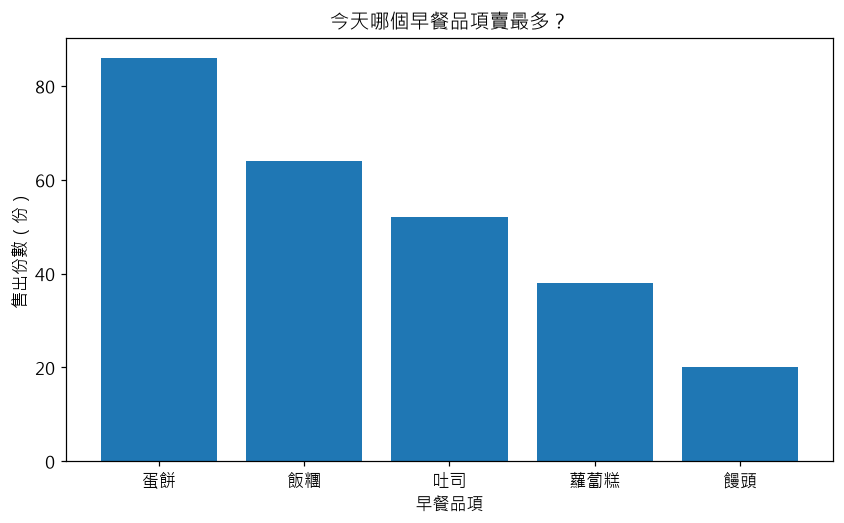

這五種品項合計： 260 份


In [2]:
items = ["蛋餅", "飯糰", "吐司", "蘿蔔糕", "饅頭"]
sales = [86, 64, 52, 38, 20]
fig, ax = plt.subplots()
ax.bar(items, sales)
ax.set(title="今天哪個早餐品項賣最多？", xlabel="早餐品項", ylabel="售出份數（份）")
ax.set_ylim(bottom=0)
plt.show()
print("這五種品項合計：", sum(sales), "份")


**技術拆解：為什麼這樣寫？**

`plt.subplots()` 回傳兩個物件：`fig` 是整張畫紙，`ax` 是畫紙內的座標區。`fig, ax =` 把兩個結果分別接住。一張畫紙可以有多個座標區，本例只有一個。

`ax.bar(x, height)` 第一個值決定類別位置，第二個值決定長條高度。第 1 個品項對應第 1 個份數，所以兩份串列長度必須一樣。`ax.set()` 一次設定標題與軸名稱，`plt.show()` 顯示圖，不負責計算銷量。

蛋餅 86 份高於饅頭 20 份，可以說今天這五類中蛋餅銷量最高，不能直接說蛋餅最賺錢；還缺售價與成本。

**課堂操作與討論**

先不執行，畫出長條高度的相對順序。把饅頭改為 90 份，再解釋排名與合計如何改變。

<details><summary>參考思路（先做再展開）</summary>

原合計 260 份；改後合計 330 份，饅頭變最高。備料還要考慮剩貨、缺貨與星期差異，不能只憑一天決定。

</details>


### 範例 02｜從CSV讀取早餐銷量

範例檔：[02_從CSV讀取早餐銷量.py](./Data_Visualization_src/bar_plot_examples/02_從CSV讀取早餐銷量.py)

檔案：`01_早餐店品項銷量.csv`。真正的工作常拿到試算表匯出的 CSV，先看懂每列是一個品項。


    品項  份數
0   蛋餅  86
1   飯糰  64
2   吐司  52
3  蘿蔔糕  38
4   饅頭  20
品項      str
份數    int64
dtype: object


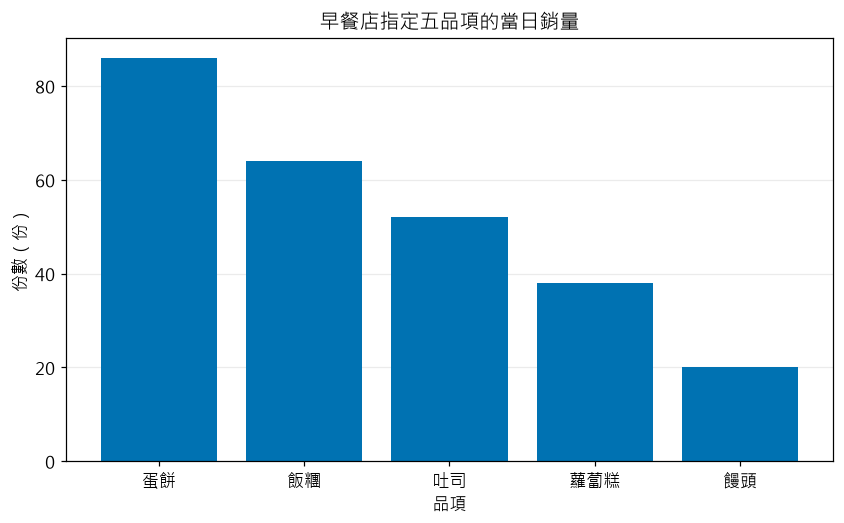

In [3]:
df = pd.read_csv(DATA / "01_早餐店品項銷量.csv", encoding="utf-8-sig")
print(df)
print(df.dtypes)
fig, ax = plt.subplots()
ax.bar(df["品項"], df["份數"], color="#0072B2")
ax.set(title="早餐店指定五品項的當日銷量", xlabel="品項", ylabel="份數（份）")
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.25)
plt.show()


**技術拆解：為什麼這樣寫？**

`pd.read_csv()` 把檔案讀成表格，`df["品項"]` 取文字欄，`df["份數"]` 取數值欄。`encoding="utf-8-sig"` 對應本教材 CSV 的編碼，不能假定所有外部檔案都是同一編碼。`grid(axis="y")` 用淡水平線協助讀高度；`set_axisbelow(True)` 把格線放到長條後面。

**課堂操作與討論**

把欄名故意寫成「銷量」，看錯誤最後一行，再用 `df.columns.tolist()` 找出真正欄名。修回來後再執行。

<details><summary>參考思路（先做再展開）</summary>

會找不到欄位，不是畫圖工具壞掉。程式必須使用表格的「份數」；顯示給讀者的 y 軸名稱可以另外寫成「當日銷量（份）」。

</details>


### 範例 03｜長條寬度與數值標籤

範例檔：[03_長條寬度與數值標籤.py](./Data_Visualization_src/bar_plot_examples/03_長條寬度與數值標籤.py)

檔案：`01_早餐店品項銷量.csv`。圖能看出誰多，但老闆還想直接看到精確數字。


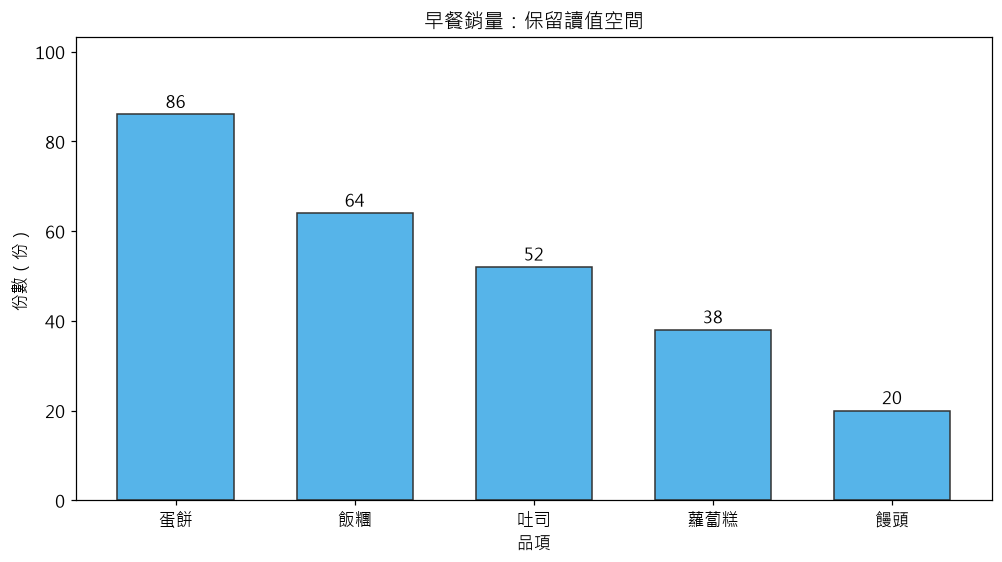

In [4]:
df = read_data("01_早餐店品項銷量.csv")
fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
bars = ax.bar(df["品項"], df["份數"], width=0.65, color="#56B4E9", edgecolor="#333333")
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set(title="早餐銷量：保留讀值空間", xlabel="品項", ylabel="份數（份）")
ax.set_ylim(0, df["份數"].max() * 1.2)
plt.show()


**技術拆解：為什麼這樣寫？**

`bar()` 回傳一組長條容器，存在 `bars`。`bar_label(bars)` 對這組長條加數字；`fmt="%.0f"` 表示以零位小數顯示，`padding=3` 是文字離長條端點的距離。標籤格式不會改掉原始資料。

類別中心通常相隔 1 個座標單位，`width=0.65` 讓每根占 0.65，留下空隙。寬度是視覺設定，不代表銷量。`set_ylim` 多留 20% 的頭頂空間，避免文字被邊界切掉；`layout="constrained"` 協助安排標題與軸名稱。

**課堂操作與討論**

分別把 width 改成 0.3、0.95，哪個適合投影？再把上限設為 86，觀察最高標籤的位置。

<details><summary>參考思路（先做再展開）</summary>

資料相同，寬窄只影響閱讀。上限太低可能裁掉標籤；應留白，不應為塞進文字而改資料。

</details>


### 範例 04｜橫向長條讀懂每月支出

範例檔：[04_橫向長條讀懂每月支出.py](./Data_Visualization_src/bar_plot_examples/04_橫向長條讀懂每月支出.py)

檔案：`02_租屋族每月支出.csv`。項目名稱很長，垂直排在下方會擠在一起，改成橫向更好讀。


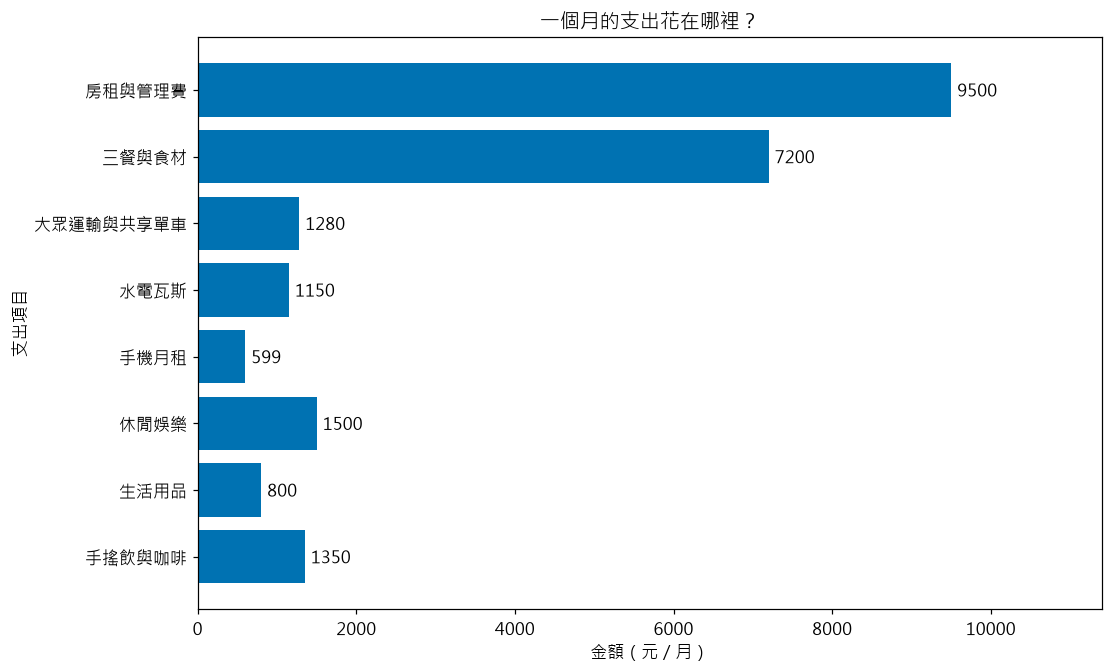

In [5]:
df = read_data("02_租屋族每月支出.csv")
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
bars = ax.barh(df["項目"], df["金額"], color="#0072B2")
ax.invert_yaxis()
ax.bar_label(bars, fmt="%.0f", padding=4)
ax.set(title="一個月的支出花在哪裡？", xlabel="金額（元／月）", ylabel="支出項目")
ax.set_xlim(0, df["金額"].max() * 1.2)
plt.show()


**技術拆解：為什麼這樣寫？**

`barh(y, width)` 中，類別放 y，數值決定往右的長度；它的數值軸是 x，所以改上限要用 `set_xlim()`。第一個類別預設在下方，`invert_yaxis()` 反轉類別方向，讓表格第一列顯示在最上面。這不是把金額變負數。

**課堂操作與討論**

同一份資料改回直向，需要交換哪些方法與標籤？若名稱換成兩個字，是否仍一定要橫向？

<details><summary>參考思路（先做再展開）</summary>

改為 bar、xlabel 項目、ylabel 金額、set_ylim；不再 invert_yaxis。橫向不是強制規定，重點是文字與數值好讀。

</details>


### 範例 05｜排序排名與同分處理

範例檔：[05_排序排名與同分處理.py](./Data_Visualization_src/bar_plot_examples/05_排序排名與同分處理.py)

檔案：`02_租屋族每月支出.csv`。想找最值得回頭檢查的支出，先依金額由大到小排列。


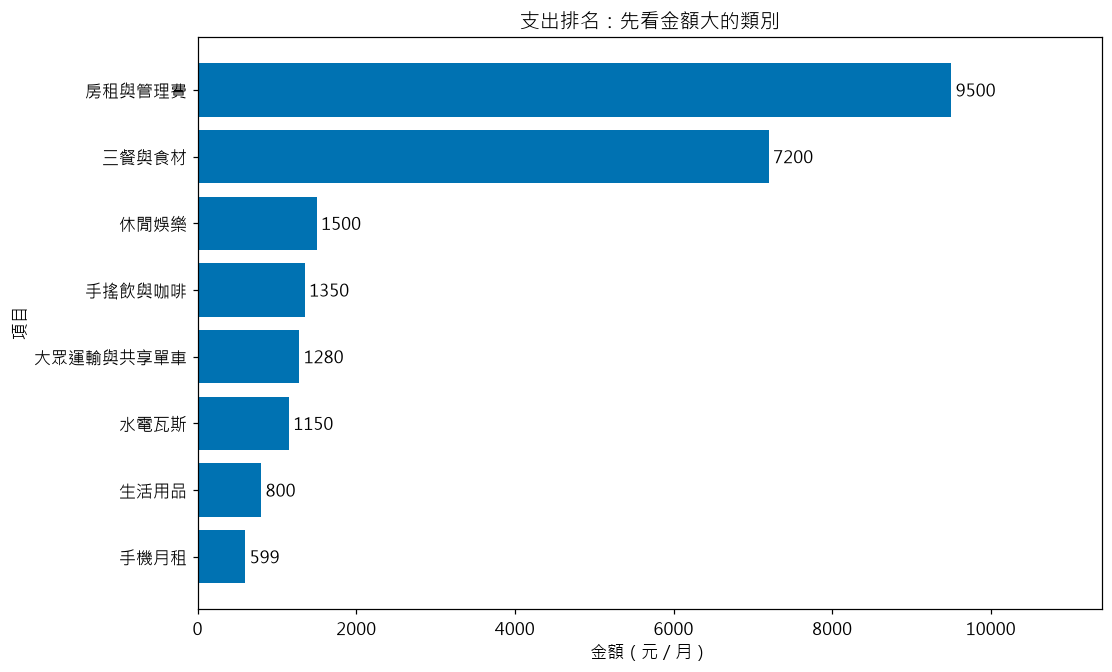

          項目    金額
0     房租與管理費  9500
1      三餐與食材  7200
5       休閒娛樂  1500
7     手搖飲與咖啡  1350
2  大眾運輸與共享單車  1280
3       水電瓦斯  1150
6       生活用品   800
4       手機月租   599


In [6]:
df = read_data("02_租屋族每月支出.csv")
ranked = df.sort_values(["金額", "項目"], ascending=[False, True])
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
bars = ax.barh(ranked["項目"], ranked["金額"], color="#0072B2")
ax.invert_yaxis()
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set(xlabel="金額（元／月）", ylabel="項目", title="支出排名：先看金額大的類別")
ax.set_xlim(0, ranked["金額"].max() * 1.2)
plt.show()
print(ranked[["項目", "金額"]])


**技術拆解：為什麼這樣寫？**

排序要移動整列，讓項目與金額仍配對。`ascending=[False, True]` 先按金額降冪，再按名稱的文字排序打破同額順序；文字排序不是「哪個更重要」。不能把金額另外排序、卻仍用原本的類別欄畫圖。星期、滿意度這種有自然順序的類別，也不一定應按數值大小重排。

**課堂操作與討論**

租金最大是否代表應先砍租金？請列出「金額大」與「可調整性高」的差別。

<details><summary>參考思路（先做再展開）</summary>

租金可能短期無法改，飲料或娛樂雖小但較容易調整。圖給出排序，實際行動還需合約、需求與可替代性。

</details>


### 範例 06｜零點基準與截斷座標

範例檔：[06_零點基準與截斷座標.py](./Data_Visualization_src/bar_plot_examples/06_零點基準與截斷座標.py)

兩家店同規格雞蛋各賣 95 與 100 元。這是內嵌示意資料，故意做一張會放大差異的圖來練習辨識。


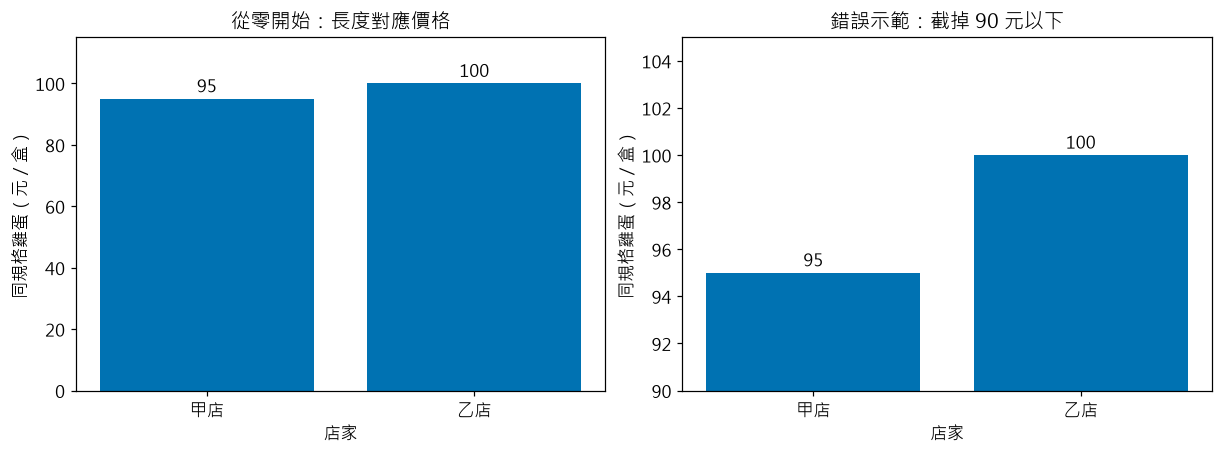

乙比甲貴 5 元；約 5.3 %


In [7]:
stores, prices = ["甲店", "乙店"], [95, 100]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax in axes:
    bars = ax.bar(stores, prices, color="#0072B2")
    ax.bar_label(bars, padding=3)
    ax.set(ylabel="同規格雞蛋（元／盒）", xlabel="店家")
axes[0].set(title="從零開始：長度對應價格", ylim=(0, 115))
axes[1].set(title="錯誤示範：截掉 90 元以下", ylim=(90, 105))
plt.show()
print("乙比甲貴", 100 - 95, "元；約", round((100 / 95 - 1) * 100, 1), "%")


**技術拆解：為什麼這樣寫？**

人會用長條「露出的長度」比較大小。右圖露出的高度是 5 與 10，看起來像兩倍，實際價格卻不是兩倍。一般長條圖應保留有意義的零基準；如果需要放大很小的差異，改用點圖並清楚標刻度，比切掉長條底部更合適。負數長條則以 0 分開兩個方向。

**課堂操作與討論**

請不用「看起來差很多」描述兩店差異。再問：乙比甲貴百分之幾，與甲比乙便宜百分之幾，數字相同嗎？

<details><summary>參考思路（先做再展開）</summary>

差 5 元；乙以甲為分母約貴 5.3%，甲以乙為分母便宜 5%。百分比比較一定要說基準。

</details>


### 範例 07｜顏色強調與黑白列印

範例檔：[07_顏色強調與黑白列印.py](./Data_Visualization_src/bar_plot_examples/07_顏色強調與黑白列印.py)

檔案：`01_早餐店品項銷量.csv`。把最高銷量標出來，不需要讓每根都變成搶眼顏色。


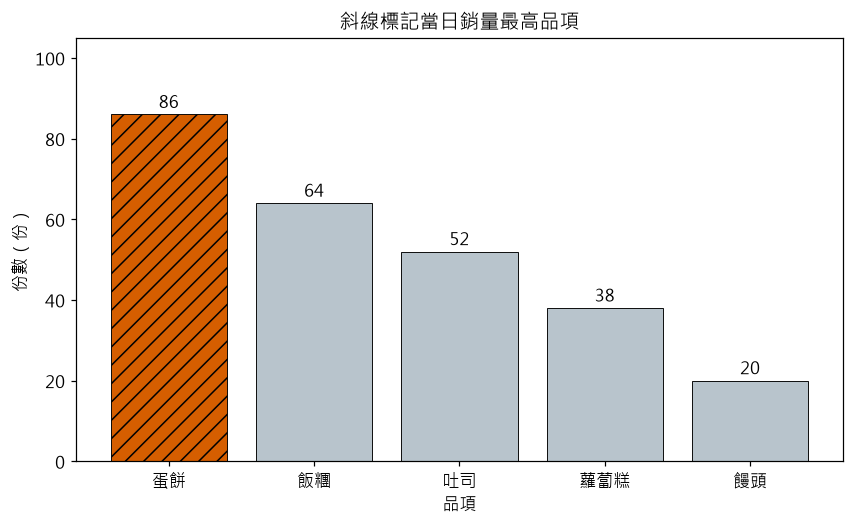

In [8]:
df = read_data("01_早餐店品項銷量.csv")
is_top = df["份數"] == df["份數"].max()
colors = ["#D55E00" if flag else "#B8C4CC" for flag in is_top]
fig, ax = plt.subplots()
bars = ax.bar(df["品項"], df["份數"], color=colors, edgecolor="black", linewidth=0.6)
for bar, flag in zip(bars, is_top):
    if flag:
        bar.set_hatch("//")
ax.bar_label(bars, padding=3)
ax.set(title="斜線標記當日銷量最高品項", xlabel="品項", ylabel="份數（份）", ylim=(0, 105))
plt.show()


**技術拆解：為什麼這樣寫？**

`is_top` 逐列判斷是否等於最大值，可保留並列第一。串列推導式把每個 True／False 換成對應顏色；`zip` 讓長條物件與判斷結果成對出現。`set_hatch("//")` 加斜線紋理，即使黑白列印，也能看出強調的品項。

**課堂操作與討論**

把飯糰也改成 86，兩根都會被標示嗎？如果只想強調老闆指定的新品，應該如何改條件？

<details><summary>參考思路（先做再展開）</summary>

兩根同為最高會一起標示。新品應用 `df["品項"] == "指定品項"`，並把標題改成強調新品，不能仍寫最高。

</details>


### 先整理資料：份數、筆數、平均與總額是四件事

假設有三張蛋餅訂單，金額 40、80、120 元，每份 40 元。訂單**張數**是 3，售出**份數**是 1+2+3=6，**營業額**是 240 元，**平均每單金額**是 240÷3=80 元。

`groupby` 像把同類收據放入同一個信封；`sum` 是信封內數字相加；`size` 是有幾筆紀錄；`count` 是某欄有多少非缺漏值；`mean` 是該欄有效數值的平均。缺值或多份訂單出現時，這些數字更不能混用。

如果你已經整理成每類一列，Matplotlib 可以直接畫；原始表中同名類別出現多次，`bar()` 不會自動把它們相加，而可能在同一位置重疊。畫之前先檢查「每列」和「每根長條」是否是同一個單位。


### 範例 08｜同一訂單表的三種比較

範例檔：[08_同一訂單表的三種比較.py](./Data_Visualization_src/bar_plot_examples/08_同一訂單表的三種比較.py)

檔案：`03_早餐店訂單明細.csv`。每列一張只買一種品項的訂單，有人一買就是多份。


   品項  訂單張數  售出份數  營業額
0  吐司     3     6  210
1  蛋餅     5     9  360
2  飯糰     4     8  360


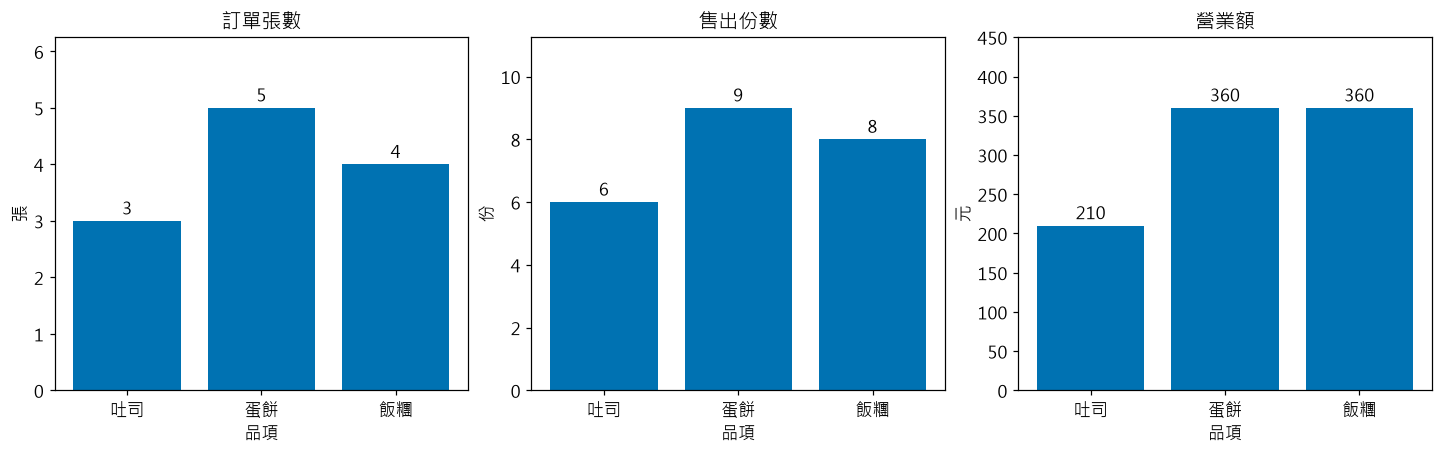

In [9]:
df = read_data("03_早餐店訂單明細.csv")
summary = df.groupby("品項", as_index=False).agg(
    訂單張數=("訂單編號", "size"), 售出份數=("份數", "sum"), 營業額=("金額", "sum"))
print(summary)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), layout="constrained")
for ax, column, unit in zip(axes, ["訂單張數", "售出份數", "營業額"], ["張", "份", "元"]):
    bars = ax.bar(summary["品項"], summary[column], color="#0072B2")
    ax.bar_label(bars, padding=3)
    ax.set(title=column, xlabel="品項", ylabel=unit, ylim=(0, summary[column].max() * 1.25))
plt.show()


**技術拆解：為什麼這樣寫？**

`agg(新欄名=(原欄名, "運算"))` 一次建立不同摘要欄，`as_index=False` 讓品項留在普通欄位。三張圖單位不同，所以各自標示，不共用 y 軸。印出摘要表可手算核對。資料中三天的蛋餅訂單最多，不一定表示蛋餅收入最多，還要看份數與單價。

**課堂操作與討論**

請手算蛋餅的張數、份數、營業額，再把結果對上三張圖。

<details><summary>參考思路（先做再展開）</summary>

蛋餅 5 張、9 份、360 元；飯糰 4 張、8 份、360 元；吐司 3 張、6 份、210 元。訂單張數不同也可能營業額相同。

</details>


### 範例 09｜通勤調查先計數再畫圖

範例檔：[09_通勤調查先計數再畫圖.py](./Data_Visualization_src/bar_plot_examples/09_通勤調查先計數再畫圖.py)

檔案：`04_同學通勤單選調查.csv`。一人一列、每人只能選一種方式，先數每個類別的人數。


主要方式
捷運     10
機車      8
公車      6
步行      4
自行車     2
Name: count, dtype: int64


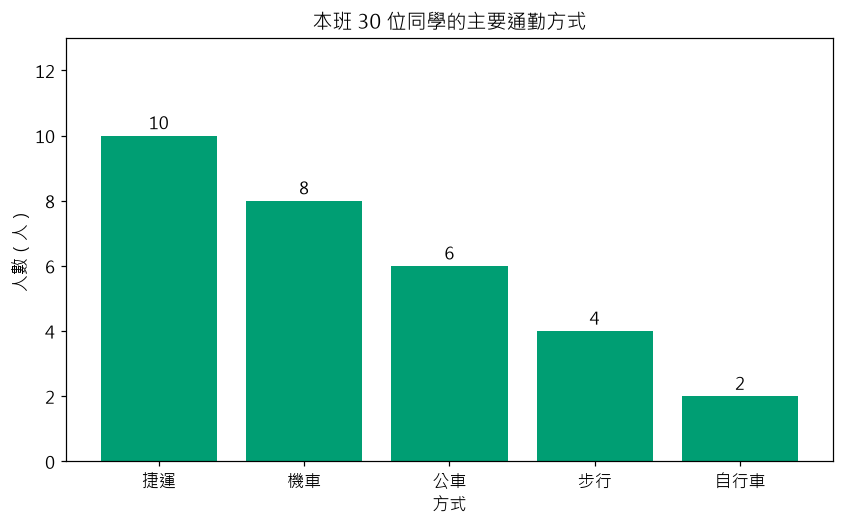

In [10]:
df = read_data("04_同學通勤單選調查.csv")
counts = df["主要方式"].value_counts()
print(counts)
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values, color="#009E73")
ax.bar_label(bars, padding=3)
ax.set(title=f"本班 {len(df)} 位同學的主要通勤方式", xlabel="方式", ylabel="人數（人）")
ax.set_ylim(0, counts.max() + 3)
plt.show()


**技術拆解：為什麼這樣寫？**

`value_counts()` 回傳各類別出現次數，預設依次數排序；`index` 是類別名稱，`values` 是人數。因本題每人一列且單選，列數才等於人數。如果每人每天記一列，就會變成紀錄次數，不是不同人的數量。

**課堂操作與討論**

若有人忘填，value_counts 預設會如何處理？把其中一筆改成缺值再檢查總人數與各類合計。

<details><summary>參考思路（先做再展開）</summary>

預設略過缺值。報告要區分受訪總人數與有效回答人數，必要時用 `dropna=False` 顯示缺漏，而不是讓分母悄悄變小。

</details>


### 範例 10｜前三大支出與其他

範例檔：[10_前三大支出與其他.py](./Data_Visualization_src/bar_plot_examples/10_前三大支出與其他.py)

檔案：`02_租屋族每月支出.csv`。向室友報告時，只想先看前三大，但不能把其他支出藏起來。


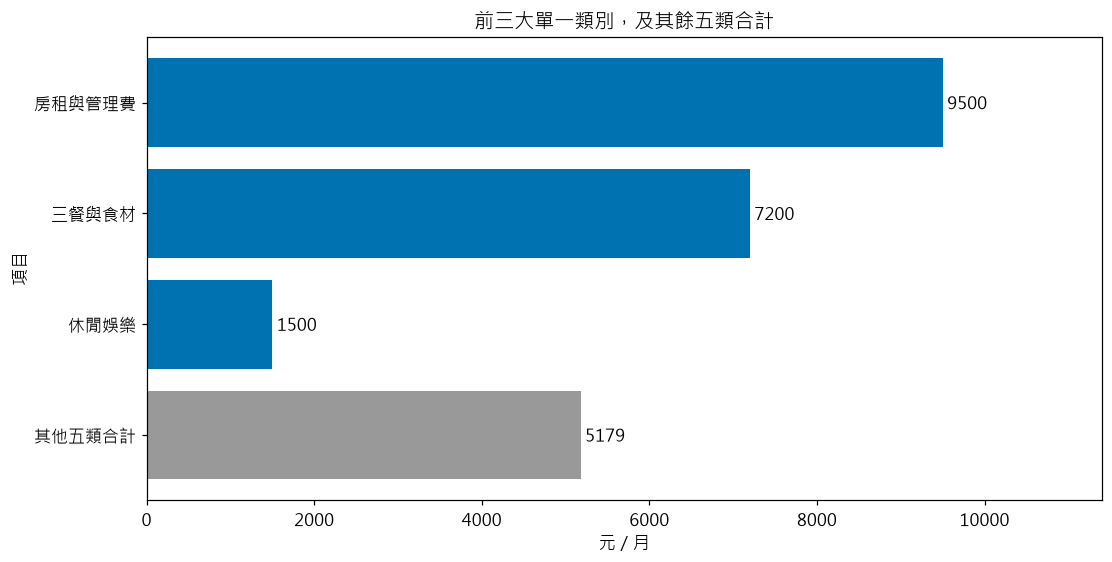

In [11]:
df = read_data("02_租屋族每月支出.csv").sort_values("金額", ascending=False)
top = df.head(3)
other = pd.DataFrame({"項目": ["其他五類合計"], "金額": [df.iloc[3:]["金額"].sum()]})
summary = pd.concat([top, other], ignore_index=True)
assert summary["金額"].sum() == df["金額"].sum()
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
bars = ax.barh(summary["項目"], summary["金額"], color=["#0072B2"] * 3 + ["#999999"])
ax.invert_yaxis()
ax.bar_label(bars, padding=3)
ax.set(title="前三大單一類別，及其餘五類合計", xlabel="元／月", ylabel="項目")
ax.set_xlim(0, summary["金額"].max() * 1.2)
plt.show()


**技術拆解：為什麼這樣寫？**

`head(3)` 取前三列，`iloc[3:]` 取從第 4 列起的其餘資料。`concat` 接起兩張同欄位表格；`assert` 檢查合計是否守恆。「其他」是多類相加，可能比第三名大，所以不要把整張圖叫前四名。若第三名並列，必須另訂是只取三項還是保留所有並列項目。

**課堂操作與討論**

只畫前三大且把百分比分母也改成前三大合計，會造成什麼誤解？

<details><summary>參考思路（先做再展開）</summary>

看起來像它們占全月 100%，其實只占部分。要標明分母是全月總額，或清楚寫「前三大內部占比」。

</details>


### 群組長條的位置數學：先拿方格紙理解

同一項目要比預算和實際，若兩根都畫在 x=0，就會互相蓋住。做法是把類別中心設為 0、1、2……，再把預算往左挪一點、實際往右挪一點。

假設每根寬 0.36：預算中心在 `x - 0.18`，實際中心在 `x + 0.18`。兩根合計占 0.72，類別中心相隔 1，還剩下間距。`np.arange(3)` 產生可做數學運算的 `[0, 1, 2]`；Python 普通串列不能直接減去 0.18，NumPy 陣列可以逐項計算。

若有 k 組，組別編號 i 從 0 開始，置中位移可寫成 `(i - (k - 1) / 2) * width`。先畫出兩組位置，再理解公式，無須硬背。座標上的 0、1、2 是擺放位置，最後仍要換回房租、餐費等文字標籤。


### 範例 11｜預算與實際並排比較

範例檔：[11_預算與實際並排比較.py](./Data_Visualization_src/bar_plot_examples/11_預算與實際並排比較.py)

檔案：`05_預算與實際支出.csv`。月底檢查哪幾類超過自己訂的預算。


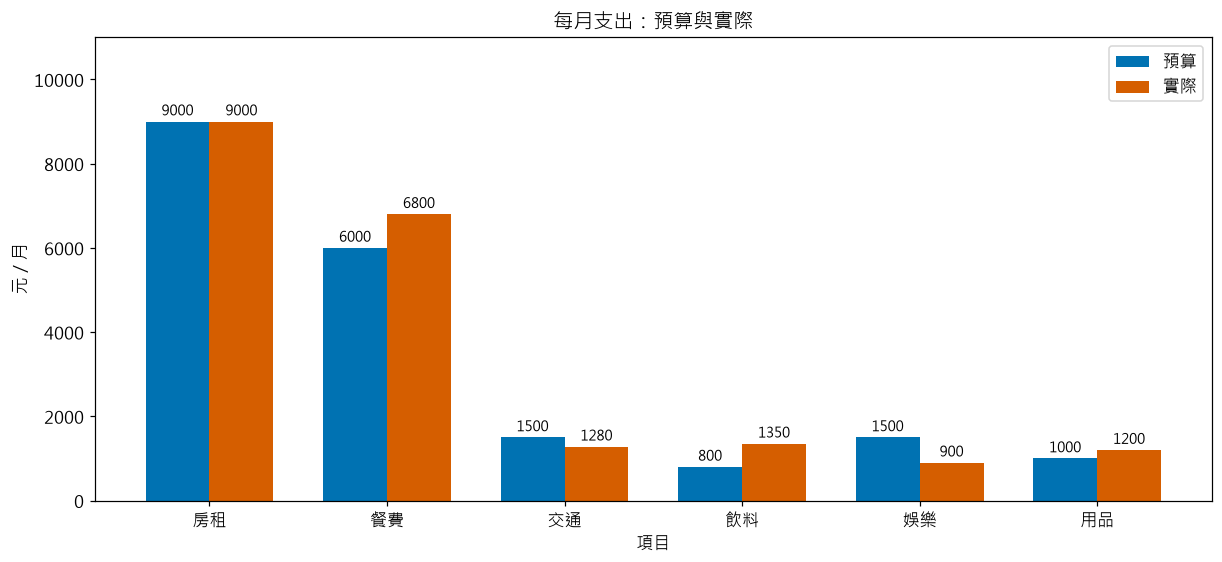

In [12]:
df = read_data("05_預算與實際支出.csv")
x = np.arange(len(df))
width = 0.36
fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
planned = ax.bar(x - width / 2, df["預算"], width=width, label="預算", color="#0072B2")
actual = ax.bar(x + width / 2, df["實際"], width=width, label="實際", color="#D55E00")
ax.set_xticks(x, df["項目"])
ax.bar_label(planned, padding=3, fontsize=9)
ax.bar_label(actual, padding=3, fontsize=9)
ax.set(title="每月支出：預算與實際", xlabel="項目", ylabel="元／月", ylim=(0, 11000))
ax.legend()
plt.show()


**技術拆解：為什麼這樣寫？**

`x - width/2` 與 `x + width/2` 只移動長條位置，不會改金額。`set_xticks(x, df["項目"])` 在每組正中央放類別名稱，避免刻度落在其中一根上。`label` 幫兩組取名，`legend()` 顯示圖例。預算與實際是同一項支出的兩種狀態，不應堆疊成「總花費」。

**課堂操作與討論**

若忘記加減位移會發生什麼？如果把兩組用堆疊畫，9000 元預算加 9000 元實際會讓人誤以為多少？

<details><summary>參考思路（先做再展開）</summary>

會在同一位置重疊；堆疊房租會到 18000，卻不是實際支出。要比較狀態用並排，要表示可加總的組成才堆疊。

</details>


### 範例 12｜三種午餐方式的群組位置

範例檔：[12_三種午餐方式的群組位置.py](./Data_Visualization_src/bar_plot_examples/12_三種午餐方式的群組位置.py)

檔案：`06_一週午餐三種方式.csv`。五個平日，每天比較自備、店內、外送三個情境。


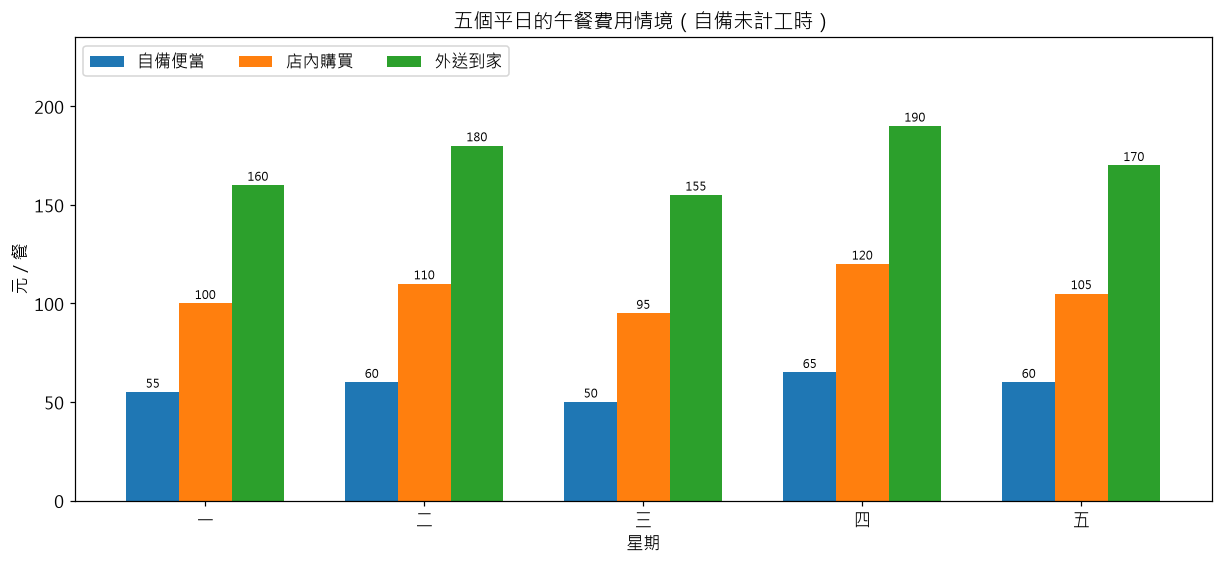

In [13]:
df = read_data("06_一週午餐三種方式.csv")
methods = ["自備便當", "店內購買", "外送到家"]
x = np.arange(len(df))
width = 0.24
fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
for i, method in enumerate(methods):
    offset = (i - (len(methods) - 1) / 2) * width
    bars = ax.bar(x + offset, df[method], width=width, label=method)
    ax.bar_label(bars, padding=2, fontsize=8)
ax.set_xticks(x, df["星期"])
ax.set(title="五個平日的午餐費用情境（自備未計工時）", xlabel="星期", ylabel="元／餐", ylim=(0, 235))
ax.legend(ncols=3, loc="upper left")
plt.show()


**技術拆解：為什麼這樣寫？**

三組位移是 −width、0、+width，讓每個星期的整組置中。迴圈 `enumerate(methods)` 同時提供第幾組和欄名，比複製貼上三次更容易保持一致。每組有三根，不是把十五根全部依費用排序，因為我們還要比較同一天的選擇。

**課堂操作與討論**

假如新增「公司餐廳」第四種方式，公式是否仍置中？為什麼可能需要減小 width？

<details><summary>參考思路（先做再展開）</summary>

四組位移是 −1.5w、−0.5w、0.5w、1.5w，仍置中；總寬約 4w，太大會碰到隔壁星期。

</details>


### 範例 13｜外送午餐貴在哪裡

範例檔：[13_外送午餐貴在哪裡.py](./Data_Visualization_src/bar_plot_examples/13_外送午餐貴在哪裡.py)

檔案：`07_午餐費用組成.csv`。一餐的餐點費、運費、服務與包裝費可以相加，適合用堆疊呈現總額與組成。


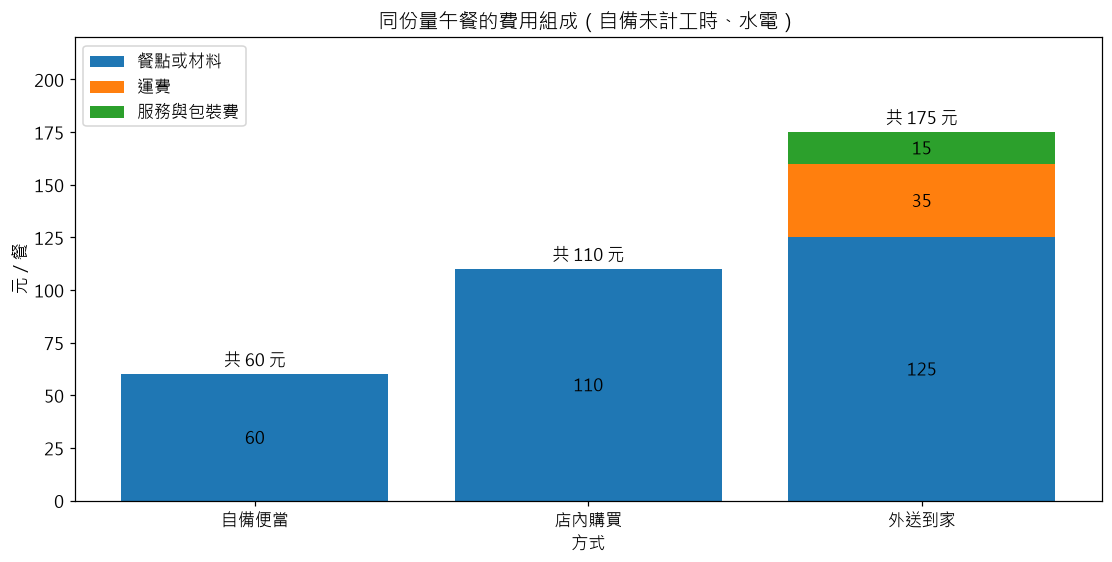

In [14]:
df = read_data("07_午餐費用組成.csv")
components = ["餐點或材料", "運費", "服務與包裝費"]
bottom = np.zeros(len(df))
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
for component in components:
    values = df[component].to_numpy()
    bars = ax.bar(df["方式"], values, bottom=bottom, label=component)
    ax.bar_label(bars, labels=[str(v) if v > 0 else "" for v in values], label_type="center")
    bottom = bottom + values
ax.bar_label(bars, labels=[f"共 {v:.0f} 元" for v in bottom], padding=4)
ax.set(title="同份量午餐的費用組成（自備未計工時、水電）", xlabel="方式", ylabel="元／餐", ylim=(0, 220))
ax.legend(loc="upper left")
plt.show()


**技術拆解：為什麼這樣寫？**

`bottom` 是每段長條從哪個高度開始。第一層從零開始，畫完把第一層數值加到 bottom，第二層就站在第一層上。`label_type="center"` 把各段金額放在段中間；最後一組長條頂端可標總額。各組成必須同單位、互不重複，才有相加意義。

**課堂操作與討論**

外送餐點 125、運費 35、服務包裝 15，總額多少？如果外送欄已含運費，還能再加一次嗎？

<details><summary>參考思路（先做再展開）</summary>

總額 175 元。已含運費就不能再加，否則重複計算。堆疊中間區塊不共享零基線，小差異通常比並排難比較。

</details>


### 範例 14｜三戶支出總額與百分比

範例檔：[14_三戶支出總額與百分比.py](./Data_Visualization_src/bar_plot_examples/14_三戶支出總額與百分比.py)

檔案：`08_三戶租屋支出.csv`。住戶各固定兩人，想同時看誰花得多，以及支出結構有何不同。


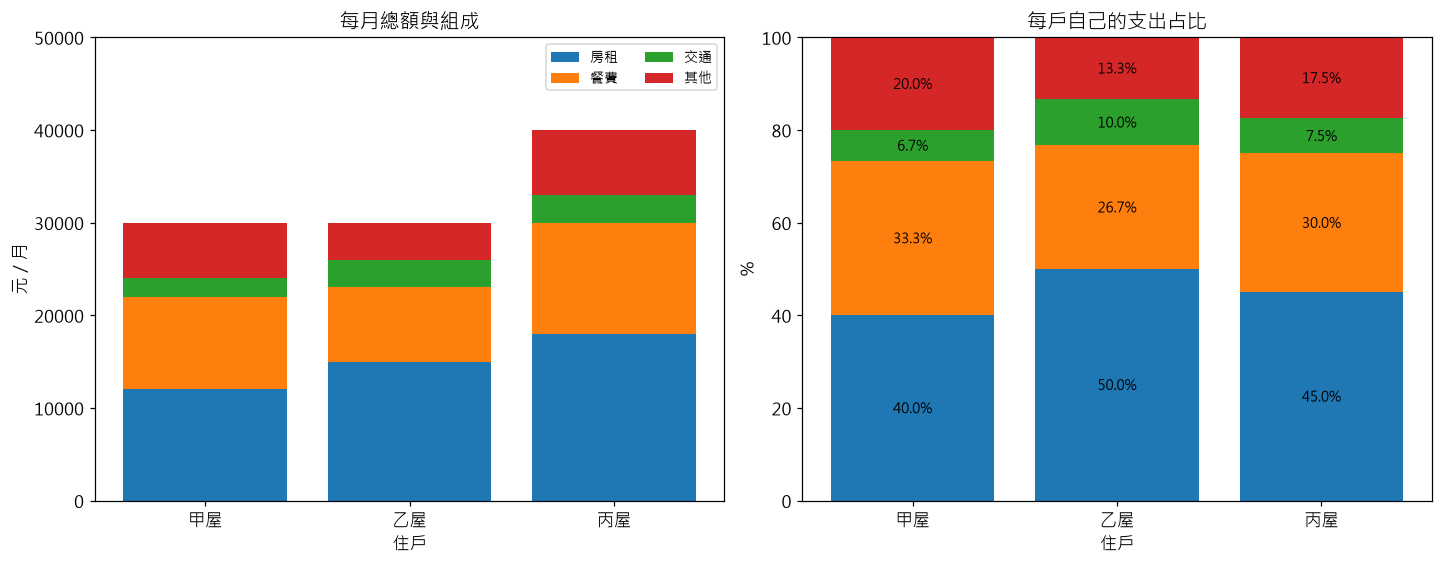

   住戶    總支出
0  甲屋  30000
1  乙屋  30000
2  丙屋  40000


In [15]:
df = read_data("08_三戶租屋支出.csv")
parts = ["房租", "餐費", "交通", "其他"]
amounts = df[parts]
totals = amounts.sum(axis=1)
assert (totals > 0).all()
percent = amounts.div(totals, axis=0) * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for ax, table, title, unit in zip(axes, [amounts, percent], ["每月總額與組成", "每戶自己的支出占比"], ["元／月", "%"]):
    bottom = np.zeros(len(df))
    for part in parts:
        bars = ax.bar(df["住戶"], table[part], bottom=bottom, label=part)
        if unit == "%":
            ax.bar_label(bars, fmt="%.1f%%", label_type="center", fontsize=9)
        bottom += table[part].to_numpy()
    ax.set(title=title, xlabel="住戶", ylabel=unit)
axes[0].set_ylim(0, totals.max() * 1.25)
axes[0].legend(ncols=2, fontsize=9)
axes[1].set_ylim(0, 100)
plt.show()
print(pd.DataFrame({"住戶": df["住戶"], "總支出": totals}))


**技術拆解：為什麼這樣寫？**

`sum(axis=1)` 是橫向把同一戶的四個項目加起來；預設 `axis=0` 是沿著列往下加，兩者分母不同。`div(totals, axis=0)` 按每一列對應的總額相除；甲屋房租占比是 12000÷30000=40%。

100% 堆疊把每戶都拉到一樣高，方便比較結構，卻隱藏總金額大小，所以搭配總額圖。百分比加總若因四捨五入成 99.9% 或 100.1%，不代表資料一定錯；計算要保留原始精度，顯示時再取小數。

**課堂操作與討論**

甲乙都花 30000 元，丙花 40000 元；如果兩戶餐費占比相同，餐費金額一定相同嗎？

<details><summary>參考思路（先做再展開）</summary>

不一定，分母不同金額就可能不同。比例比較也不能推論誰經濟壓力最大，因為尚未提供收入。

</details>


### 範例 15｜零杯與尚未回報

範例檔：[15_零杯與尚未回報.py](./Data_Visualization_src/bar_plot_examples/15_零杯與尚未回報.py)

檔案：`09_飲料店盤點缺漏.csv`。綠茶確定售出 0 杯，奶茶尚未回報。把空白補零，會把「不知道」說成「沒賣出」。


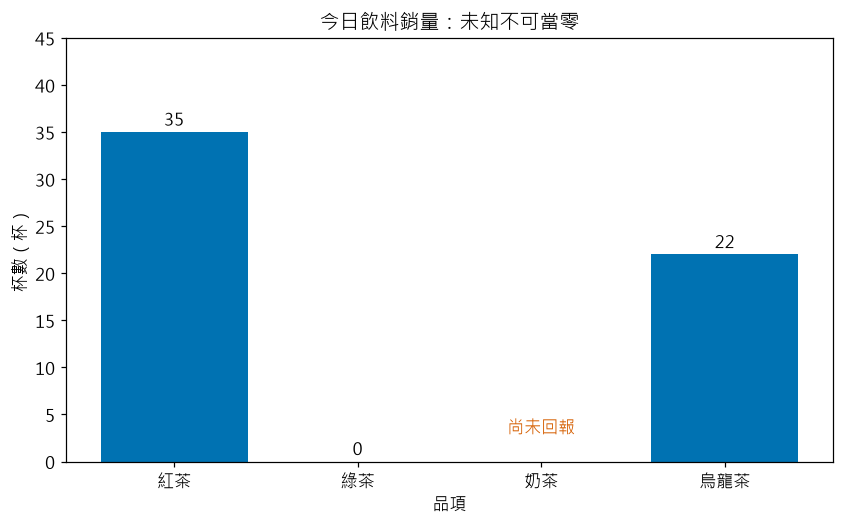

已知銷量合計： 57.0 杯；缺漏項目： ['奶茶']


In [16]:
df = read_data("09_飲料店盤點缺漏.csv")
x = np.arange(len(df))
known = df["杯數"].notna()
fig, ax = plt.subplots()
bars = ax.bar(x[known], df.loc[known, "杯數"], color="#0072B2")
ax.bar_label(bars, fmt="%.0f", padding=3)
for position in x[~known]:
    ax.text(position, 3, "尚未回報", ha="center", color="#D55E00")
ax.set_xticks(x, df["品項"])
ax.set(title="今日飲料銷量：未知不可當零", xlabel="品項", ylabel="杯數（杯）", ylim=(0, 45))
plt.show()
print("已知銷量合計：", df["杯數"].sum(min_count=1), "杯；缺漏項目：", df.loc[~known, "品項"].tolist())


**技術拆解：為什麼這樣寫？**

`notna()` 找已知值；`~known` 把條件反轉。只畫已知值，但所有類別位置仍保留；未知加文字，確定的零有 0 標籤。`sum(min_count=1)` 在所有值都缺漏時回傳 NaN，避免預設加總的 0 被誤讀為真的零。

**課堂操作與討論**

這三個已知品項可否算占「全店銷量」比例？可以怎麼命名才正確？

<details><summary>參考思路（先做再展開）</summary>

全店總量未知，不能算全店占比；可以明寫「已回報品項內部占比」，並列出缺漏品項。已知合計 57 杯，不是已確認的全店合計。

</details>


### 範例 16｜正負差額看超支與結餘

範例檔：[16_正負差額看超支與結餘.py](./Data_Visualization_src/bar_plot_examples/16_正負差額看超支與結餘.py)

檔案：`05_預算與實際支出.csv`。房租金額很大，會讓小類別差異不明顯；直接畫「實際減預算」更容易找超支。


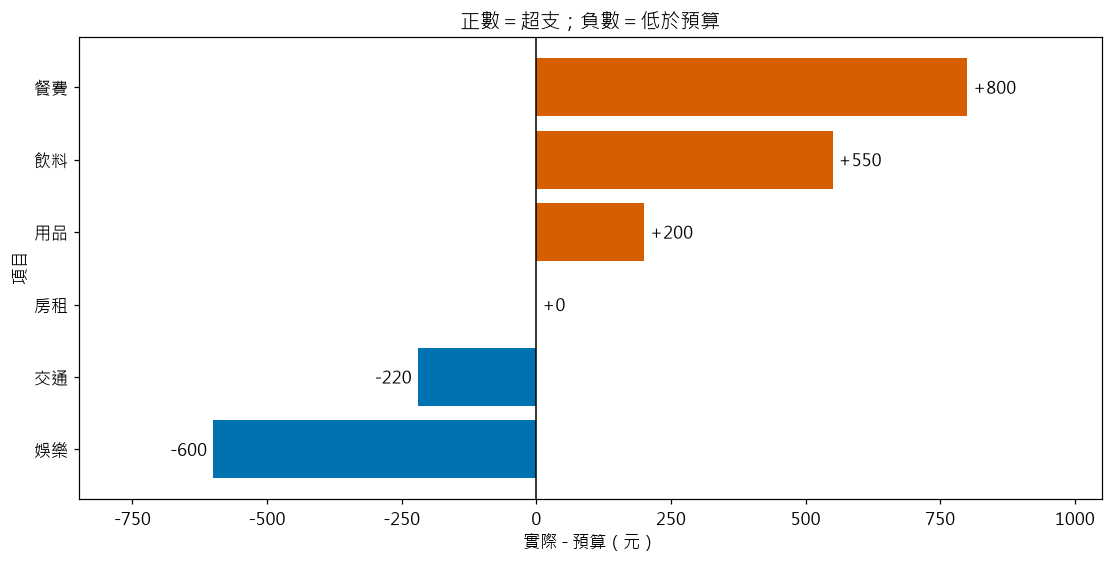

整體預算差額： 730 元


In [17]:
df = read_data("05_預算與實際支出.csv")
df["差額"] = df["實際"] - df["預算"]
df = df.sort_values("差額", ascending=False)
colors = ["#D55E00" if value > 0 else "#0072B2" for value in df["差額"]]
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
bars = ax.barh(df["項目"], df["差額"], color=colors)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=1)
ax.bar_label(bars, fmt="%+.0f", padding=4)
ax.set(title="正數＝超支；負數＝低於預算", xlabel="實際 - 預算（元）", ylabel="項目")
ax.set_xlim(df["差額"].min() - 250, df["差額"].max() + 250)
plt.show()
print("整體預算差額：", df["差額"].sum(), "元")


**技術拆解：為什麼這樣寫？**

差額定義先講清楚；若改成預算減實際，正負意義就反過來。`axvline(0)` 標出左右共同基準，`%+.0f` 顯示正負號。負數不是「花了負的錢」，而是實際比預算少。這是差額圖，不應把 x 下限硬設為 0 把負值裁掉。

**課堂操作與討論**

餐費超支 800、娛樂少花 600，兩項抵銷後是多少？「超支項目合計」和「總差額」相同嗎？

<details><summary>參考思路（先做再展開）</summary>

兩項合起來超支 200。只加正差額不允許節省項目抵銷，因此與整體差額不同，要分別命名。

</details>


### 範例 17｜雞蛋盒價與每顆單價

範例檔：[17_雞蛋盒價與每顆單價.py](./Data_Visualization_src/bar_plot_examples/17_雞蛋盒價與每顆單價.py)

檔案：`10_超市雞蛋包裝比價.csv`。不同包裝看盒價不公平，先換成每顆同單位再比較。


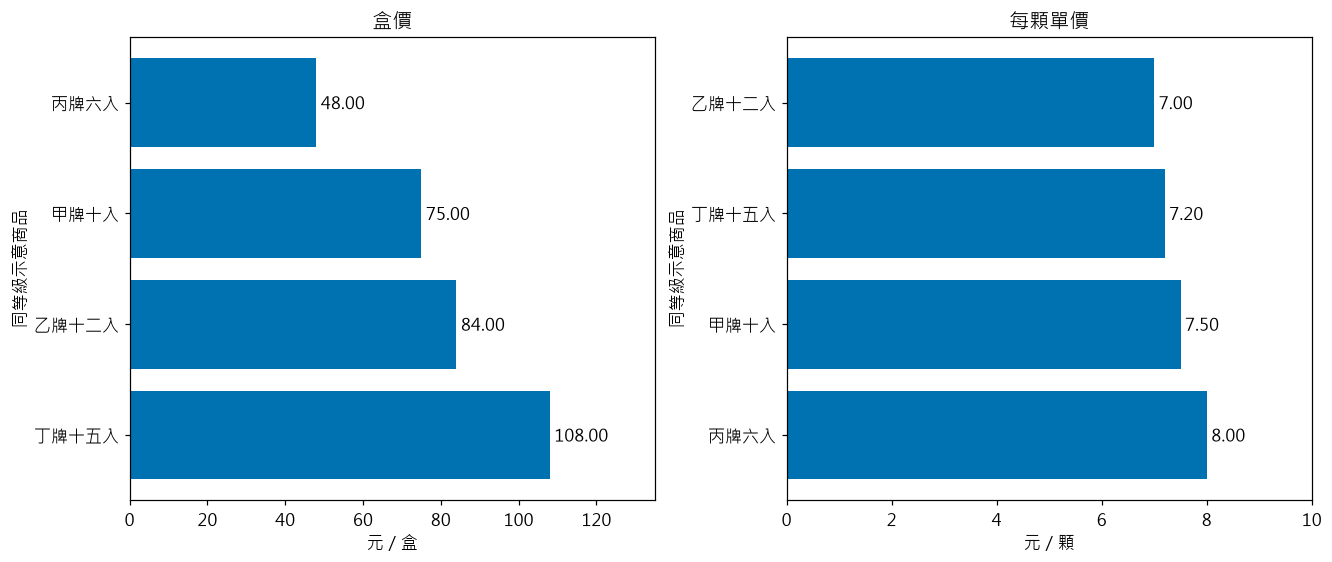

      商品   盒價  顆數  每顆單價
0   甲牌十入   75  10   7.5
1  乙牌十二入   84  12   7.0
2   丙牌六入   48   6   8.0
3  丁牌十五入  108  15   7.2


In [18]:
df = read_data("10_超市雞蛋包裝比價.csv")
assert (df["顆數"] > 0).all()
df["每顆單價"] = df["盒價"] / df["顆數"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
for ax, column, unit in zip(axes, ["盒價", "每顆單價"], ["元／盒", "元／顆"]):
    ranked = df.sort_values(column)
    bars = ax.barh(ranked["商品"], ranked[column], color="#0072B2")
    ax.invert_yaxis()
    ax.bar_label(bars, fmt="%.2f", padding=3)
    ax.set(title=column, xlabel=unit, ylabel="同等級示意商品")
    ax.set_xlim(0, ranked[column].max() * 1.25)
plt.show()
print(df)


**技術拆解：為什麼這樣寫？**

`盒價 / 顆數` 是逐列相除，得到每顆價格。先檢查顆數大於零，避免除以零。兩張圖可以各自排序，因為它們問不同問題；單位也必須分開。不要先把 7.2 四捨五入成 7 才排序，可能把真實價差隱藏掉。

**課堂操作與討論**

盒價最便宜是哪個？每顆最便宜是哪個？如果一個人吃不完大盒，最低單價是否一定最划算？

<details><summary>參考思路（先做再展開）</summary>

丙牌六入盒價 48 元最低；乙牌十二入每顆 7 元最低。還需考慮保存期限、浪費與實際需求。

</details>


### 範例 18｜超市比價報告與輸出

範例檔：[18_超市比價報告與輸出.py](./Data_Visualization_src/bar_plot_examples/18_超市比價報告與輸出.py)

檔案：`10_超市雞蛋包裝比價.csv`。把計算與圖交給家人，讓對方不看程式也能讀懂。


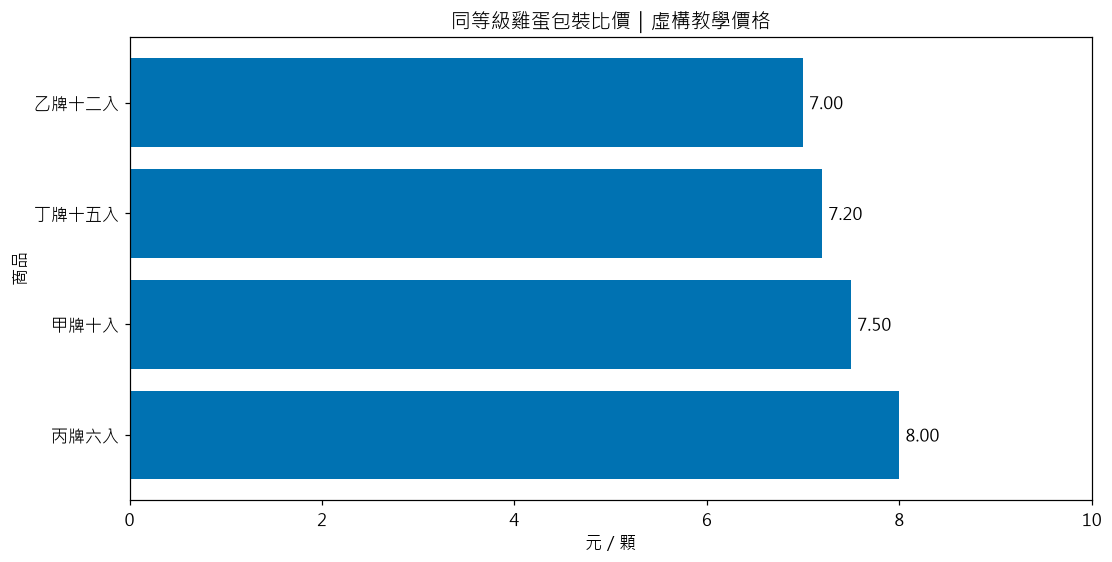

在本題同等級的假設下，最低每顆單價為 7.00 元。
尚未納入保存期限、促銷與吃不完的浪費。


In [19]:
df = read_data("10_超市雞蛋包裝比價.csv")
df["每顆單價"] = df["盒價"] / df["顆數"]
df = df.sort_values("每顆單價")
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
bars = ax.barh(df["商品"], df["每顆單價"], color="#0072B2")
ax.invert_yaxis()
ax.bar_label(bars, fmt="%.2f", padding=4)
ax.set(title="同等級雞蛋包裝比價｜虛構教學價格", xlabel="元／顆", ylabel="商品", xlim=(0, 10))
fig.savefig(OUT / "18_雞蛋單價比較.png", dpi=160, bbox_inches="tight")
fig.savefig(OUT / "18_雞蛋單價比較.svg", bbox_inches="tight")
df.to_csv(OUT / "18_雞蛋單價摘要.csv", index=False, encoding="utf-8-sig")
plt.show()
print(f"在本題同等級的假設下，最低每顆單價為 {df.iloc[0]['每顆單價']:.2f} 元。")
print("尚未納入保存期限、促銷與吃不完的浪費。")


**技術拆解：為什麼這樣寫？**

`fig.savefig()` 明確存這張圖，放在 `show()` 前容易掌握。PNG 是像素圖，dpi 決定解析度；SVG 可縮放。`bbox_inches="tight"` 保留標籤並減少多餘留白。`to_csv(index=False)` 不把列索引另存成資料欄；保留每顆單價原始精度，圖只顯示兩位小數。

**課堂操作與討論**

把圖縮成簡報半頁，檢查中文、數字、單位與限制是否看得清楚。為什麼只交圖、不交摘要表可能不方便？

<details><summary>參考思路（先做再展開）</summary>

摘要表讓讀者核對公式與精確數字，圖適合比較。兩者一起交付，才容易更換價格後重算。

</details>


### 第一部分停下來練習

先完成工作單 A、B、C，再看範例 31–33 的參考解答。老師可以要求先交草圖、再交程式，最後說明一個自己修正的錯誤。

- A：預算差額。依 05 CSV 畫超支與低於預算的項目，零基準、正負號、總差額都要清楚。
- B：雞蛋比價。依 10 CSV 畫每顆單價，精度保留，不把最低盒價當最低單價。
- C：早餐訂單。依 03 CSV 比較各品項總份數與營業額，不能用列數替代份數。

## 第二部分｜使用 Seaborn

Matplotlib 像自己擺放每根長條，Seaborn 像交出表格後說「請依欄位幫我整理與分組」。仍可用 Matplotlib 的 `ax.set()`、`bar_label()`、`savefig()` 做後續調整。

**最重要的預設：`sns.barplot()` 會把同類別的數值取平均，預設附平均估計的信賴區間。它不會自動猜到你想要總營業額。** `errorbar=None` 只關掉誤差線，不會關掉平均。

折線圖學過的 `estimator=None` 不應直接照搬到 barplot；barplot 需要把每類數值整理成一個代表值。已彙整成每類一列時，可用 `estimator="sum", errorbar=None` 明確表示畫總額，或直接用 Matplotlib。

| 參數 | 用途 | 選擇前先想 |
|---|---|---|
| `data`、`x`、`y` | 指定表格與欄名 | y 是元、份還是分鐘？ |
| `estimator` | 每類的平均、總和或中位數 | 題目要的代表值是哪一種？ |
| `errorbar` | 誤差線的定義，或 None | 分散程度與平均不確定性不能混說 |
| `order` | 主類別順序 | 排名或自然順序？ |
| `hue`、`hue_order` | 再依第二個類別並排分組 | 同一顏色是否始終代表同一組？ |
| `palette`、`color` | 分組配色或單一色 | 顏色傳達什麼？ |
| `dodge`、`gap` | 分組位移與組內間距 | 只是外觀，不能改統計意義 |
| `ax` | 指定畫進哪個座標區 | 用於 barplot；catplot 自建整張圖 |

下面先從每類只有一筆的資料開始，再處理同類多筆資料。


### 範例 19｜Seaborn第一張早餐長條圖

範例檔：[19_Seaborn第一張早餐長條圖.py](./Data_Visualization_src/bar_plot_examples/19_Seaborn第一張早餐長條圖.py)

檔案：`01_早餐店品項銷量.csv`。同一份資料改用欄位名稱作圖，與第一部分核對高度。


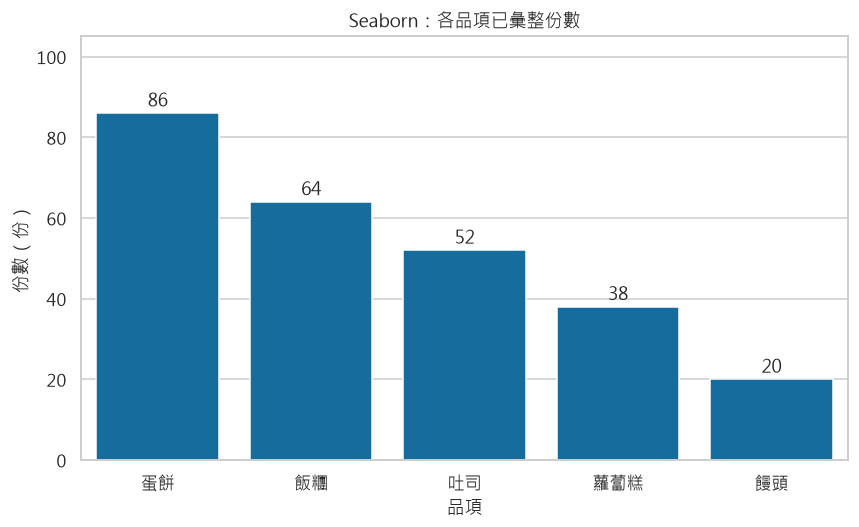

In [20]:
df = read_data("01_早餐店品項銷量.csv")
sns.set_theme(style="whitegrid", font=font, rc={"axes.unicode_minus": False})
fig, ax = plt.subplots()
sns.barplot(data=df, x="品項", y="份數", estimator="sum", errorbar=None, color="#0072B2", ax=ax)
label_bars(ax)
ax.set(title="Seaborn：各品項已彙整份數", xlabel="品項", ylabel="份數（份）", ylim=(0, 105))
plt.show()


**技術拆解：為什麼這樣寫？**

`data=df` 先交代表格，再用 `x="品項"`、`y="份數"` 指定欄名，不用手動先取出兩欄。每品項一列，sum 與 mean 此時數值相同，但明寫 sum 能交代目的。`ax=ax` 放進指定座標區；`label_bars()` 是教材小工具，依序替所有長條容器加數字。`set_theme` 會改全域樣式，也要傳中文字型。

**課堂操作與討論**

把一個品項拆成兩列後，sum 與 mean 還會相同嗎？先用蛋餅拆成 40、46 份想一遍。

<details><summary>參考思路（先做再展開）</summary>

sum 仍為 86；mean 變成 43。所以資料形狀一變，原本不易察覺的預設平均就會改變圖意義。

</details>


### 範例 20｜預設平均與總營業額的差別

範例檔：[20_預設平均與總營業額的差別.py](./Data_Visualization_src/bar_plot_examples/20_預設平均與總營業額的差別.py)

檔案：`03_早餐店訂單明細.csv`。同一個 y 欄金額，用不同 estimator 就會回答不同問題。


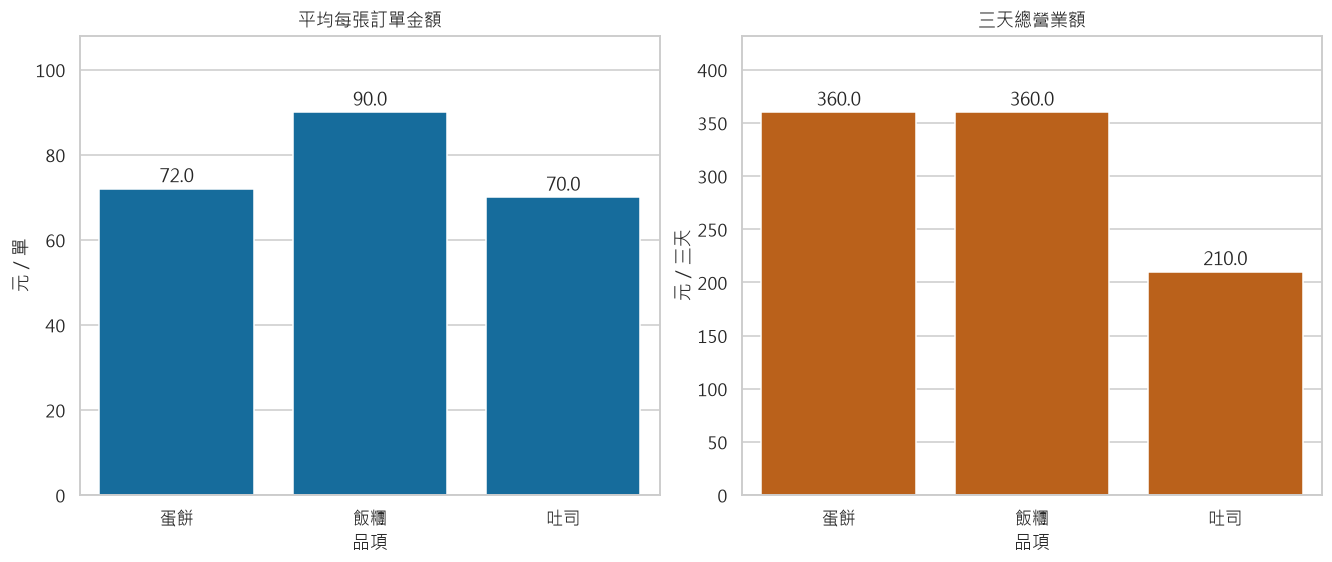

    mean  sum  size
品項                 
吐司  70.0  210     3
蛋餅  72.0  360     5
飯糰  90.0  360     4


In [21]:
df = read_data("03_早餐店訂單明細.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
sns.barplot(data=df, x="品項", y="金額", estimator="mean", errorbar=None, color="#0072B2", ax=axes[0])
sns.barplot(data=df, x="品項", y="金額", estimator="sum", errorbar=None, color="#D55E00", ax=axes[1])
axes[0].set(title="平均每張訂單金額", ylabel="元／單", xlabel="品項")
axes[1].set(title="三天總營業額", ylabel="元／三天", xlabel="品項")
for ax in axes:
    label_bars(ax, fmt="%.1f")
    ax.margins(y=0.2)
plt.show()
print(df.groupby("品項")["金額"].agg(["mean", "sum", "size"]))


**技術拆解：為什麼這樣寫？**

`estimator="mean"` 是平均，`estimator="sum"` 是加總。兩邊都設定 `errorbar=None`，只是拿掉誤差線。左圖某品項高，代表平均每張該品項訂單金額較高；不代表賣出最多張，也不代表利潤最高。

**課堂操作與討論**

若客人一次買十份，會推高哪些指標？店長問「這三天收多少」，應採左圖還是右圖？

<details><summary>參考思路（先做再展開）</summary>

會增加份數、總額，也可能拉高平均每單；訂單張數仍只加一。收款總額看右圖，且未扣成本不能叫利潤。

</details>


### 範例 21｜countplot數列數不是份數

範例檔：[21_countplot數列數不是份數.py](./Data_Visualization_src/bar_plot_examples/21_countplot數列數不是份數.py)

檔案：`03_早餐店訂單明細.csv`。計數圖只簡介到能辨識與長條統計的差別；完整計數圖可另開教材。


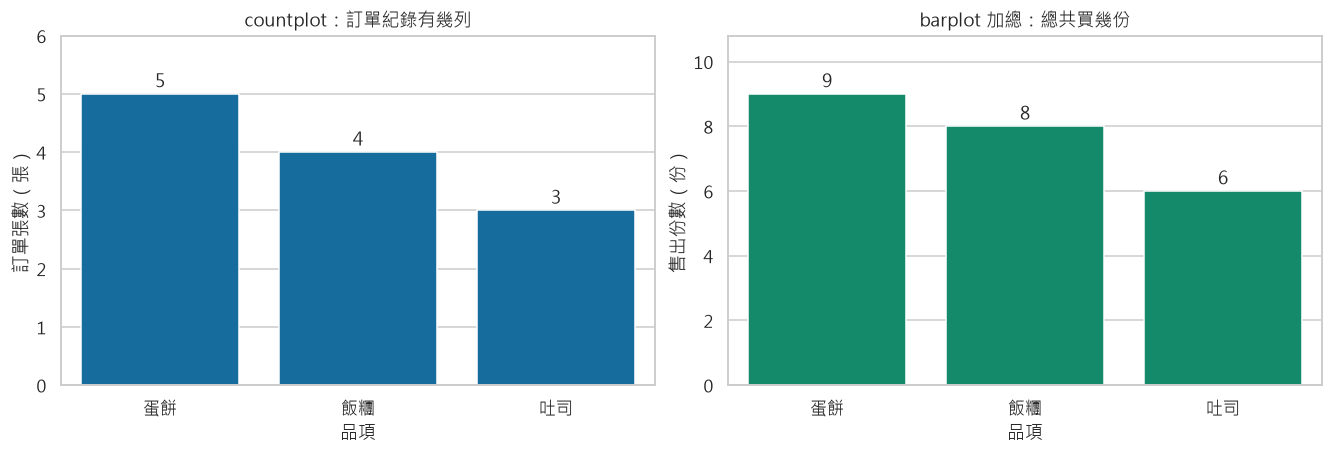

In [22]:
df = read_data("03_早餐店訂單明細.csv")
order = ["蛋餅", "飯糰", "吐司"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
sns.countplot(data=df, x="品項", order=order, color="#0072B2", ax=axes[0])
sns.barplot(data=df, x="品項", y="份數", order=order, estimator="sum", errorbar=None, color="#009E73", ax=axes[1])
axes[0].set(title="countplot：訂單紀錄有幾列", ylabel="訂單張數（張）")
axes[1].set(title="barplot 加總：總共買幾份", ylabel="售出份數（份）")
for ax in axes:
    label_bars(ax)
    ax.margins(y=0.2)
plt.show()


**技術拆解：為什麼這樣寫？**

countplot 不需要 y 數值欄，它數類別出現幾次。一張訂單有三份吐司，表格仍只有一列，所以左圖只加一。若你的資料已經是一列「蛋餅 86 份」的摘要，再用 countplot 只會數成蛋餅一列，不會畫出 86。

**課堂操作與討論**

把已彙整的 01 CSV 給 countplot，預測每個品項高度。這是程式錯誤還是問題問錯？

<details><summary>參考思路（先做再展開）</summary>

每類都是 1。程式正確數了列數，但資料層級與分析問題不合；應使用 barplot 的份數欄或 Matplotlib。

</details>


### 範例 22｜午餐寬表轉長表

範例檔：[22_午餐寬表轉長表.py](./Data_Visualization_src/bar_plot_examples/22_午餐寬表轉長表.py)

檔案：`06_一週午餐三種方式.csv`。把三種方式的欄位往下接，交給 hue 自動安排並排。


  星期    方式   費用
0  一  自備便當   55
1  二  自備便當   60
2  三  自備便當   50
3  四  自備便當   65
4  五  自備便當   60
5  一  店內購買  100
6  二  店內購買  110


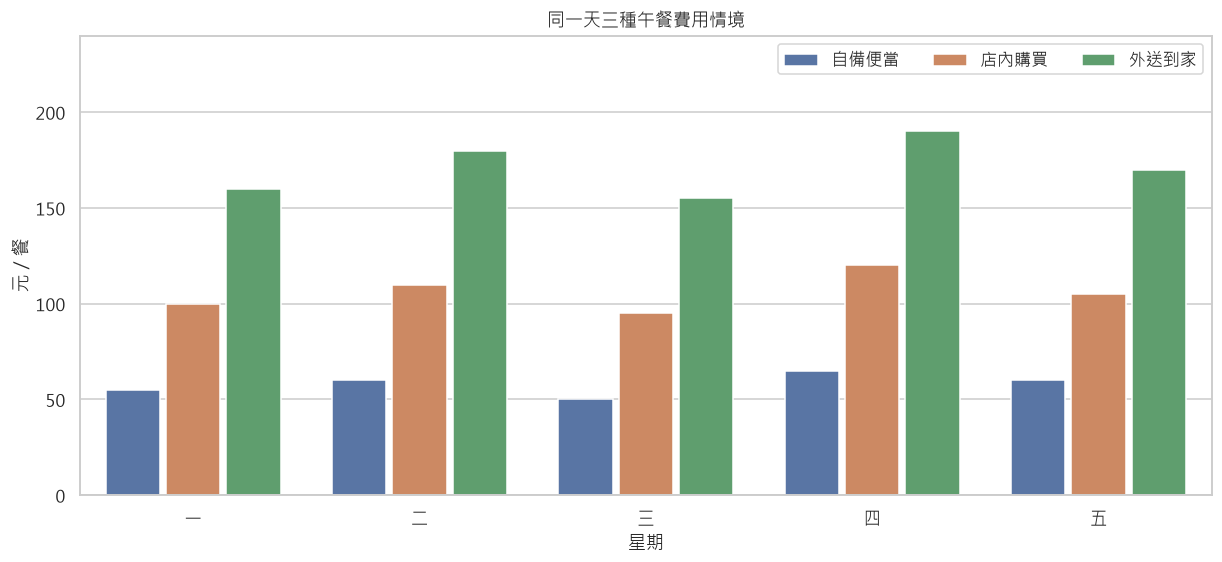

In [23]:
df = read_data("06_一週午餐三種方式.csv")
methods = ["自備便當", "店內購買", "外送到家"]
long = df.melt(id_vars="星期", value_vars=methods, var_name="方式", value_name="費用")
print(long.head(7))
assert len(long) == len(df) * 3
fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
sns.barplot(data=long, x="星期", y="費用", hue="方式", order=["一", "二", "三", "四", "五"],
            hue_order=methods, estimator="sum", errorbar=None, gap=0.1, ax=ax)
ax.set(title="同一天三種午餐費用情境", xlabel="星期", ylabel="元／餐", ylim=(0, 240))
ax.legend(ncols=3)
plt.show()


**技術拆解：為什麼這樣寫？**

`melt` 只改表格形狀，不計算平均。`id_vars` 保留星期，`value_vars` 指定搬下來的三欄，原欄名放進「方式」，原數值放進「費用」。五天乘三種方式變成十五列。`hue` 在每個星期內依方式分組，Seaborn 幫我們安排位移；`gap` 留組內空隙，是 0.13 系列功能。

**課堂操作與討論**

用紙把星期一的一列改寫成長表三列。若星期和方式的組合重複，sum 的解讀會如何改變？

<details><summary>參考思路（先做再展開）</summary>

三列分別是自備 55、店內 100、外送 160。重複組合要先查原因，可能是兩餐或重複輸入，不能無條件相加假裝還是一餐。

</details>


### 範例 23｜Seaborn橫向排名與明確順序

範例檔：[23_Seaborn橫向排名與明確順序.py](./Data_Visualization_src/bar_plot_examples/23_Seaborn橫向排名與明確順序.py)

檔案：`02_租屋族每月支出.csv`。讓類別順序由資料計算，避免以為 Seaborn 會自動按金額排名。


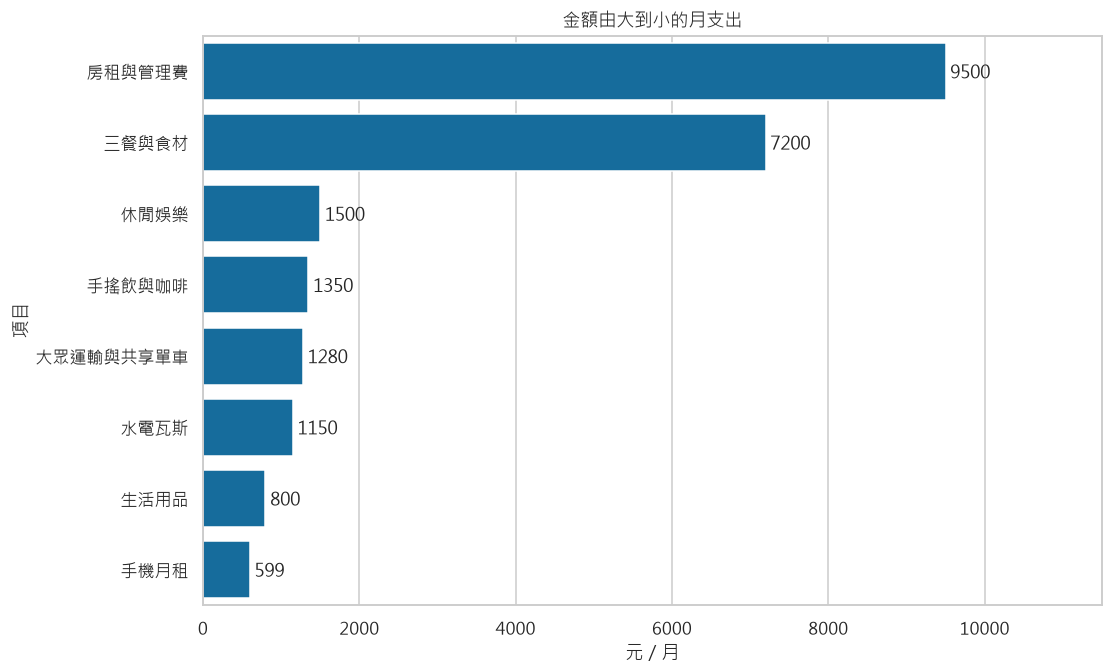

In [24]:
df = read_data("02_租屋族每月支出.csv")
order = df.sort_values("金額", ascending=False)["項目"].tolist()
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
sns.barplot(data=df, y="項目", x="金額", order=order, estimator="sum", errorbar=None, color="#0072B2", ax=ax)
label_bars(ax)
ax.set(title="金額由大到小的月支出", xlabel="元／月", ylabel="項目", xlim=(0, 11500))
plt.show()


**技術拆解：為什麼這樣寫？**

Seaborn 的 `order` 是主類別的顯示順序，即使類別在 y 軸也一樣。它只是排列，不改變金額。橫向圖透過 x 放數值、y 放文字自動判斷方向；若兩軸都是數字代碼，應明確設定 `orient`，或先把類別編號轉為有意義的文字。

**課堂操作與討論**

如果只把 order 寫成前三個名稱，其他類別會不會自動變成「其他」？

<details><summary>參考思路（先做再展開）</summary>

不會，其他類別會被排除顯示。若要保留總額，必須自己彙整其他類並清楚標示。

</details>


### 範例 24｜固定配色比較預算狀態

範例檔：[24_固定配色比較預算狀態.py](./Data_Visualization_src/bar_plot_examples/24_固定配色比較預算狀態.py)

檔案：`05_預算與實際支出.csv`。整份報告中「預算」固定藍色，「實際」固定橘色，方便學生追蹤。


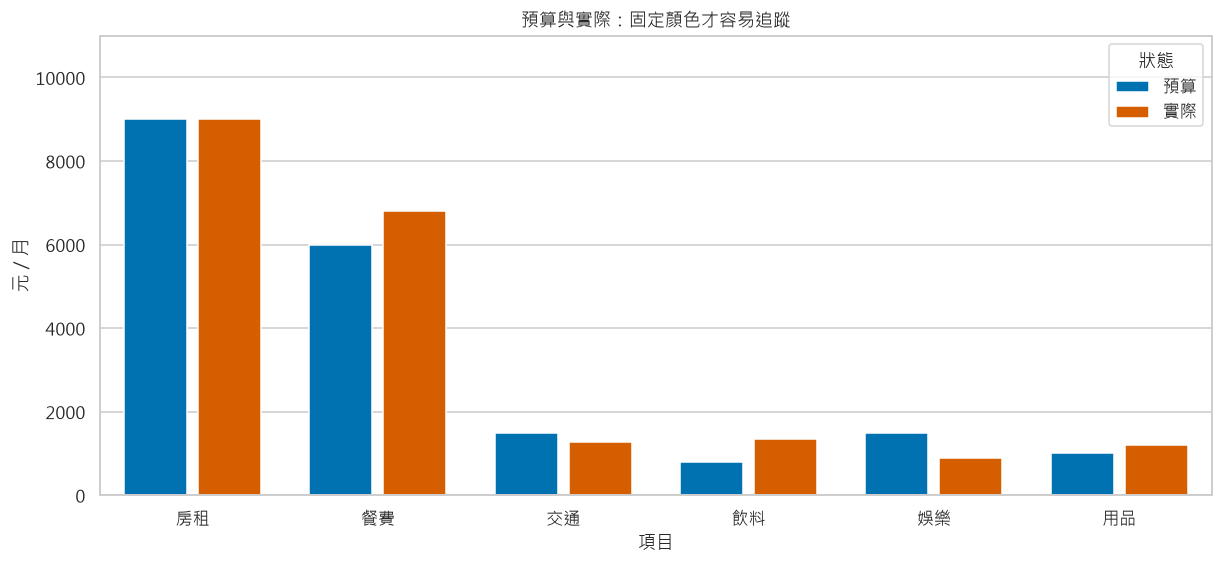

In [25]:
df = read_data("05_預算與實際支出.csv")
long = df.melt(id_vars="項目", value_vars=["預算", "實際"], var_name="狀態", value_name="金額")
palette = {"預算": "#0072B2", "實際": "#D55E00"}
fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
sns.barplot(data=long, x="項目", y="金額", hue="狀態", hue_order=["預算", "實際"],
            order=df["項目"].tolist(), palette=palette, saturation=1, estimator="sum", errorbar=None, gap=0.15, ax=ax)
ax.set(title="預算與實際：固定顏色才容易追蹤", xlabel="項目", ylabel="元／月", ylim=(0, 11000))
plt.show()


**技術拆解：為什麼這樣寫？**

`palette` 字典把類別名稱對應到顏色，資料篩選後仍維持同樣意義；`hue_order` 決定每組內誰在左、誰在右。`saturation=1` 保留指定色彩。單色圖用 `color`，分組才用 `hue` 搭配 `palette`；不要依賴沒有 hue 卻傳 palette 的舊寫法。

**課堂操作與討論**

只篩選餐費、飲料、娛樂畫第二張圖，應保留哪幾個設定？如果「實際」換成藍色會造成什麼負擔？

<details><summary>參考思路（先做再展開）</summary>

保留 palette、hue_order 與單位；觀眾才不用每張重學顏色含義。若沒有統一 y 範圍，跨圖比較還需要看刻度。

</details>


### 誤差線不是裝飾：平均值以外還要問什麼？

平均 6 分鐘可能是每個人都等 6 分鐘，也可能有人等 1 分鐘、有人等 11 分鐘。長條只給一個代表值，容易把差異藏起來。

- **標準差 SD**：原始數值散得多開。可先理解成離平均的典型距離；樣本標準差的計算是各值減平均、平方、加總、除以 n−1，最後開根號，單位回到分鐘。
- **信賴區間 CI**：在適當抽樣假設下，估計平均值的不確定性。不是「95% 的客人等候時間」範圍，更不是保證明天準時。
- **中位數 median**：把數字排好取中間值，遇到單筆超長等待通常比平均不敏感，但也會隱藏尾端風險。

Seaborn 用 bootstrap 估計 CI：從某店的觀測卡片中抽一張、記錄後放回，抽到原本樣本數，算一次平均，再重複很多次。`seed` 固定重抽的隨機序列，方便教學重現，不會把便利取樣變成隨機樣本。

本教材等待資料中每位顧客只量一次，但也不是代表所有時段的抽樣。接下來的 CI 用於認識工具；不能直接宣稱某店服務品質有顯著差異。單點或單組的區間，也不能代替整份研究設計。


### 範例 25｜等候時間的SD與CI

範例檔：[25_等候時間的SD與CI.py](./Data_Visualization_src/bar_plot_examples/25_等候時間的SD與CI.py)

檔案：`11_早餐店等候紀錄.csv`。左圖說明個體分散，右圖示範平均估計區間，兩張圖平均高度相同。


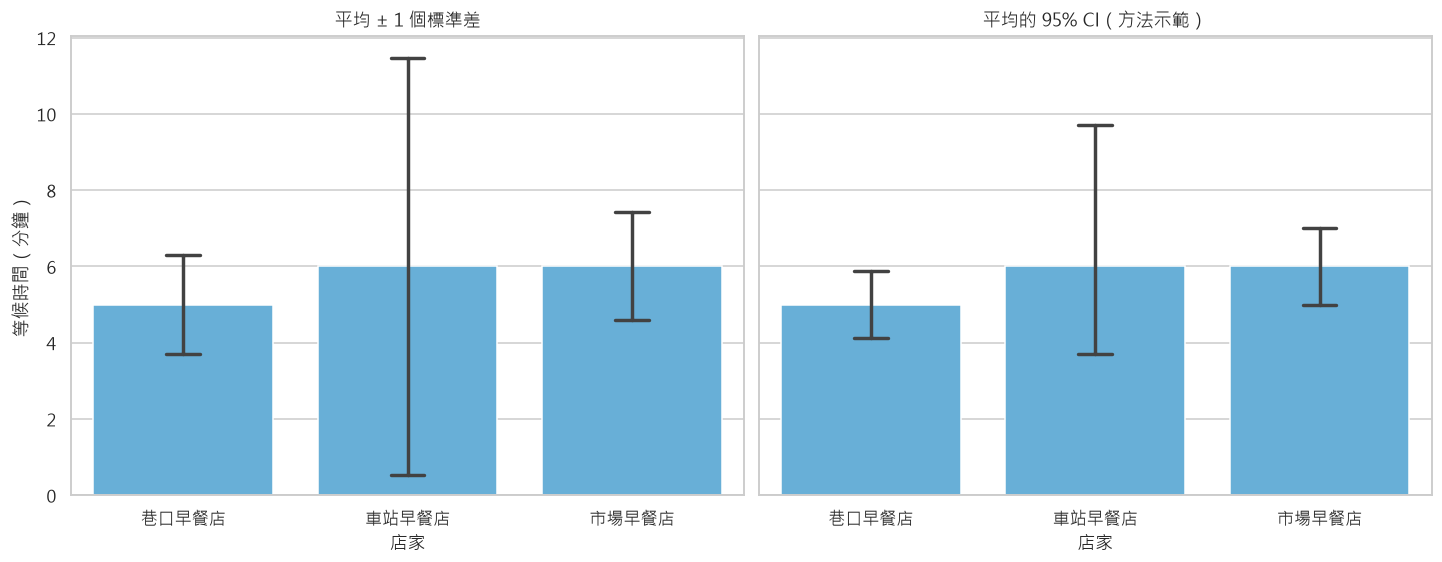

       size  mean   std  min  max
店家                               
巷口早餐店     8   5.0  1.31    3    7
市場早餐店     6   6.0  1.41    4    8
車站早餐店    10   6.0  5.48    2   21


In [26]:
df = read_data("11_早餐店等候紀錄.csv")
order = ["巷口早餐店", "車站早餐店", "市場早餐店"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, layout="constrained")
sns.barplot(data=df, x="店家", y="等候分鐘", order=order, estimator="mean", errorbar="sd", capsize=0.15, color="#56B4E9", ax=axes[0])
sns.barplot(data=df, x="店家", y="等候分鐘", order=order, estimator="mean", errorbar=("ci", 95), seed=42,
            n_boot=2000, capsize=0.15, color="#56B4E9", ax=axes[1])
axes[0].set_title("平均 ± 1 個標準差")
axes[1].set_title("平均的 95% CI（方法示範）")
for ax in axes:
    ax.set(xlabel="店家", ylabel="等候時間（分鐘）")
plt.show()
print(df.groupby("店家")["等候分鐘"].agg(["size", "mean", "std", "min", "max"]).round(2))


**技術拆解：為什麼這樣寫？**

`capsize` 控制誤差線端點的小橫線，讓區間端點容易辨認。`errorbar="sd"` 是平均上下各一個標準差，不是最小到最大；`("ci", 95)` 是 bootstrap 平均區間。SD 的下界有時可能小於零，那是對稱摘要的限制，不是負的等待時間；此時更需要原始值與合適的分布呈現。

**課堂操作與討論**

圖上的區間重疊，可以直接說兩家完全一樣嗎？如果每店只有一筆，沒有誤差線代表沒有不確定性嗎？

<details><summary>參考思路（先做再展開）</summary>

都不可以。區間重疊不能直接替代組間檢定；只有一筆時無法估計組內變異，沒有線不等於確定無誤。

</details>


### 範例 26｜平均中位數與原始等待點

範例檔：[26_平均中位數與原始等待點.py](./Data_Visualization_src/bar_plot_examples/26_平均中位數與原始等待點.py)

檔案：`11_早餐店等候紀錄.csv`。車站店有一位等了 21 分鐘，只看平均可能看不出這件事。


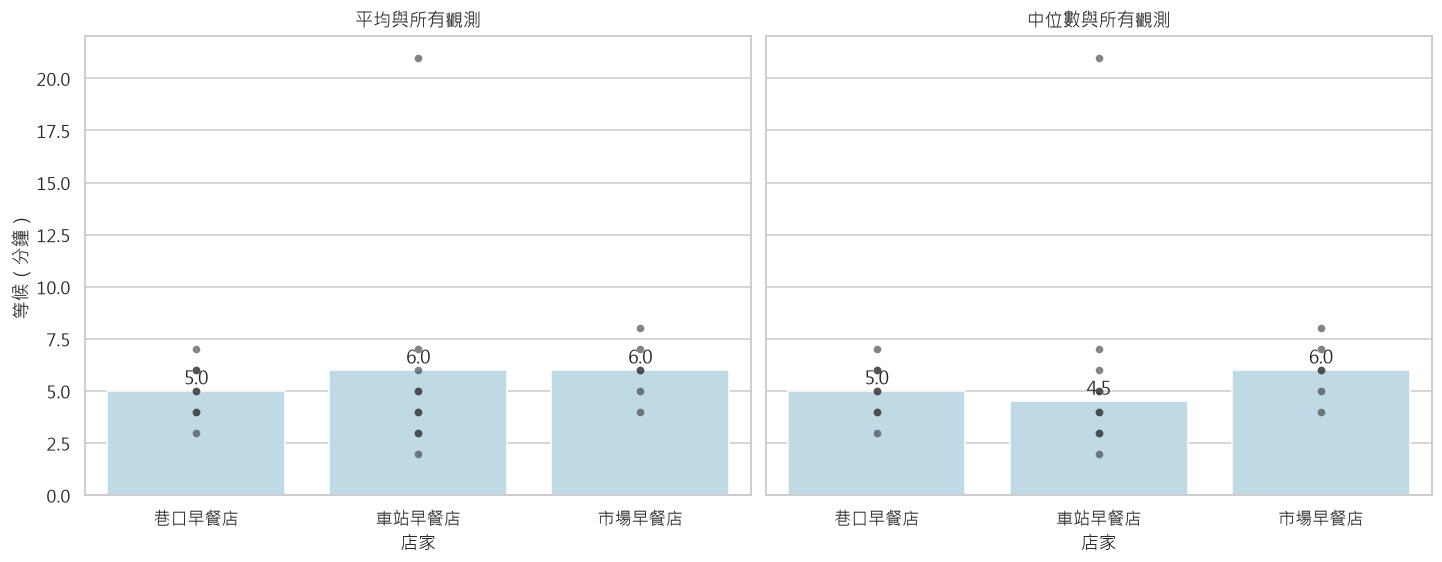

       mean  median  max
店家                      
巷口早餐店   5.0     5.0    7
市場早餐店   6.0     6.0    8
車站早餐店   6.0     4.5   21


In [27]:
df = read_data("11_早餐店等候紀錄.csv")
order = ["巷口早餐店", "車站早餐店", "市場早餐店"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, layout="constrained")
for ax, estimator, title in zip(axes, ["mean", "median"], ["平均與所有觀測", "中位數與所有觀測"]):
    sns.barplot(data=df, x="店家", y="等候分鐘", order=order, estimator=estimator,
                errorbar=None, color="#B9DDEB", ax=ax)
    sns.stripplot(data=df, x="店家", y="等候分鐘", order=order, jitter=False,
                  color="#333333", size=5, alpha=0.6, ax=ax)
    label_bars(ax, fmt="%.1f")
    ax.set(title=title, xlabel="店家", ylabel="等候（分鐘）")
plt.show()
print(df.groupby("店家")["等候分鐘"].agg(["mean", "median", "max"]))


**技術拆解：為什麼這樣寫？**

stripplot 把原始值疊上去，避免長條藏掉極端值。`jitter=False` 讓圖完全固定，但相同數值會重疊；所以印出樣本數或表格仍很重要，不能數看得見的點當人數。平均容易被 21 分鐘拉高，中位數比較穩，但都不能保證你的下一次體驗。

**課堂操作與討論**

把 21 分鐘改成 41，預測哪一個代表值改變較多。可不可以只因為它不漂亮就刪掉？

<details><summary>參考思路（先做再展開）</summary>

平均上升 2 分鐘，中位數不變；不能任意刪除真實長等待。先查是否輸入錯誤，再決定如何報告，必要時保留並解釋。

</details>


### 範例 27｜不同筆數不能直接平均各組平均

範例檔：[27_不同筆數不能直接平均各組平均.py](./Data_Visualization_src/bar_plot_examples/27_不同筆數不能直接平均各組平均.py)

檔案：`12_兩週購物紀錄.csv`。第一週兩次購物、第二週八次；想知道全部十次平均每次花多少。


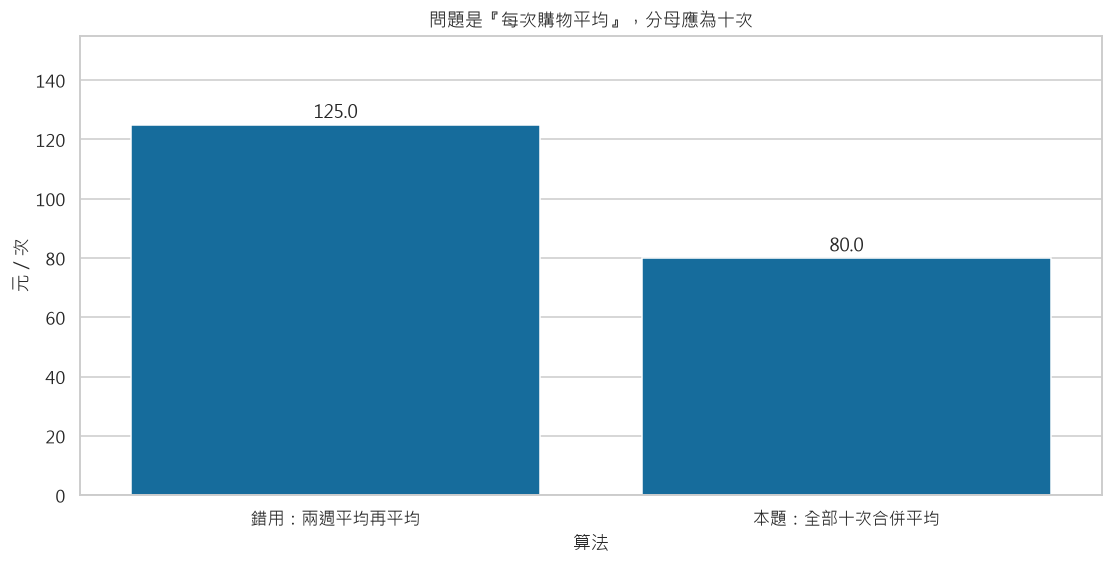

     sum  count   mean
週別                    
第一週  400      2  200.0
第二週  400      8   50.0
依次數加權的平均： 80.0


In [28]:
df = read_data("12_兩週購物紀錄.csv")
weekly = df.groupby("週別")["消費金額"].agg(["sum", "count", "mean"])
unweighted = weekly["mean"].mean()
pooled = df["消費金額"].mean()
weighted = (weekly["mean"] * weekly["count"]).sum() / weekly["count"].sum()
comparison = pd.DataFrame({"算法": ["錯用：兩週平均再平均", "本題：全部十次合併平均"], "金額": [unweighted, pooled]})
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
sns.barplot(data=comparison, x="算法", y="金額", estimator="mean", errorbar=None, color="#0072B2", ax=ax)
label_bars(ax, fmt="%.1f")
ax.set(title="問題是『每次購物平均』，分母應為十次", xlabel="算法", ylabel="元／次", ylim=(0, 155))
plt.show()
print(weekly)
print("依次數加權的平均：", weighted)


**技術拆解：為什麼這樣寫？**

第一週平均 200、第二週平均 50，直接再平均得到 125，等於讓兩週各占一半權重；但十次購物中有八次在第二週。每次消費平均應是總額 800÷10=80。用各週平均乘次數後加總，再除以總次數，也會得到 80。不是所有平均的平均都錯，而是要看你想讓「週」還是「購物次數」等權重。

**課堂操作與討論**

若兩週都是五次購物，兩種算法會相同嗎？如果題目改成「兩週各自平均單次金額的平均」，125 是否有定義？

<details><summary>參考思路（先做再展開）</summary>

等次數時會相同。125 可以是明確定義的等週權重指標，但不能標成全部十次消費的平均。

</details>


### 範例 28｜分店平假日先換成每日平均

範例檔：[28_分店平假日先換成每日平均.py](./Data_Visualization_src/bar_plot_examples/28_分店平假日先換成每日平均.py)

檔案：`13_早餐分店一週銷量.csv`。平日有五天、假日兩天，直接比總量會受到營業天數影響。


    分店  日別   每日平均  營業天數
0  住宅店  假日  121.0     2
1  住宅店  平日  107.8     5
2  市場店  假日  139.0     2
3  市場店  平日  110.2     5
4  車站店  假日   92.0     2
5  車站店  平日   89.8     5


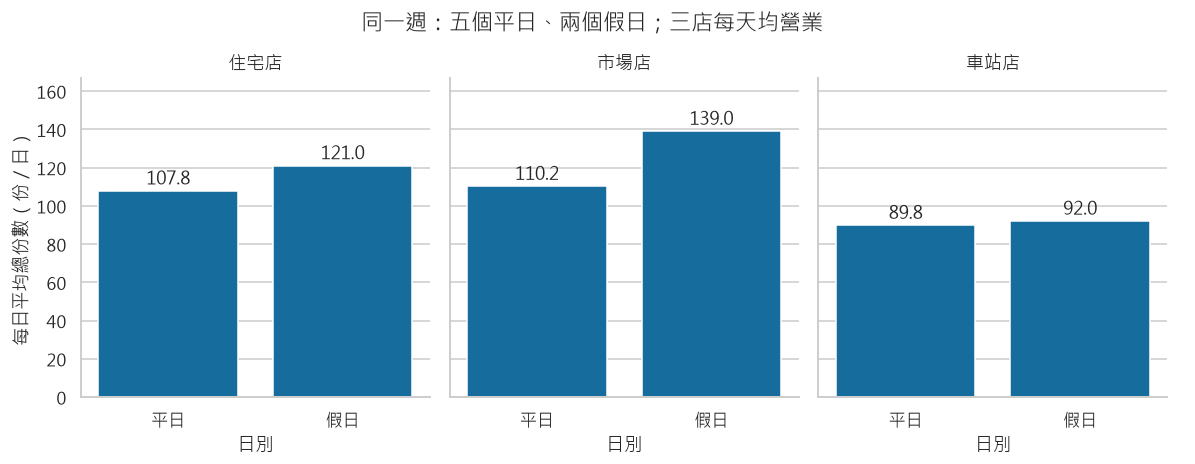

In [29]:
df = read_data("13_早餐分店一週銷量.csv")
daily = df.groupby(["日期", "日別", "分店"], as_index=False)["份數"].sum()
summary = daily.groupby(["分店", "日別"], as_index=False).agg(每日平均=("份數", "mean"), 營業天數=("日期", "nunique"))
print(summary)
g = sns.catplot(data=summary, x="日別", y="每日平均", col="分店", kind="bar",
                order=["平日", "假日"], estimator="mean", errorbar=None, color="#0072B2",
                height=4, aspect=0.9, sharey=True)
g.set_axis_labels("日別", "每日平均總份數（份／日）")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    label_bars(ax, fmt="%.1f")
    ax.set_ylim(0, summary["每日平均"].max() * 1.2)
g.figure.suptitle("同一週：五個平日、兩個假日；三店每天均營業", y=1.05)
g.savefig(OUT / "28_分店每日平均.png", dpi=160)
plt.show()


**技術拆解：為什麼這樣寫？**

`catplot(kind="bar", col="分店")` 自建多個小圖，回傳 FacetGrid，不接受把它當作一般 barplot 塞到既有 ax。先把同一天同店的兩品項相加，才得到每日總量，再比較平假日每日平均。所有小圖共享 y 尺度；已彙整平均每組一列，所以關閉誤差線，不假裝能從一個摘要值估計不確定性。

**課堂操作與討論**

如果某店週末休一天，應直接除以兩天嗎？休店的 0 與有營業卻沒回報一樣嗎？

<details><summary>參考思路（先做再展開）</summary>

要先決定問營業日平均或日曆日平均；前者按實際營業天數，後者才含確定休店零銷量。缺回報不能當零，營業日誌需另行核對。

</details>


### 範例 29｜滿意度次數與百分比結構

範例檔：[29_滿意度次數與百分比結構.py](./Data_Visualization_src/bar_plot_examples/29_滿意度次數與百分比結構.py)

檔案：`14_便當店滿意度次數.csv`。三店回覆人數不同，先保留等級順序，再換成各店內部百分比。


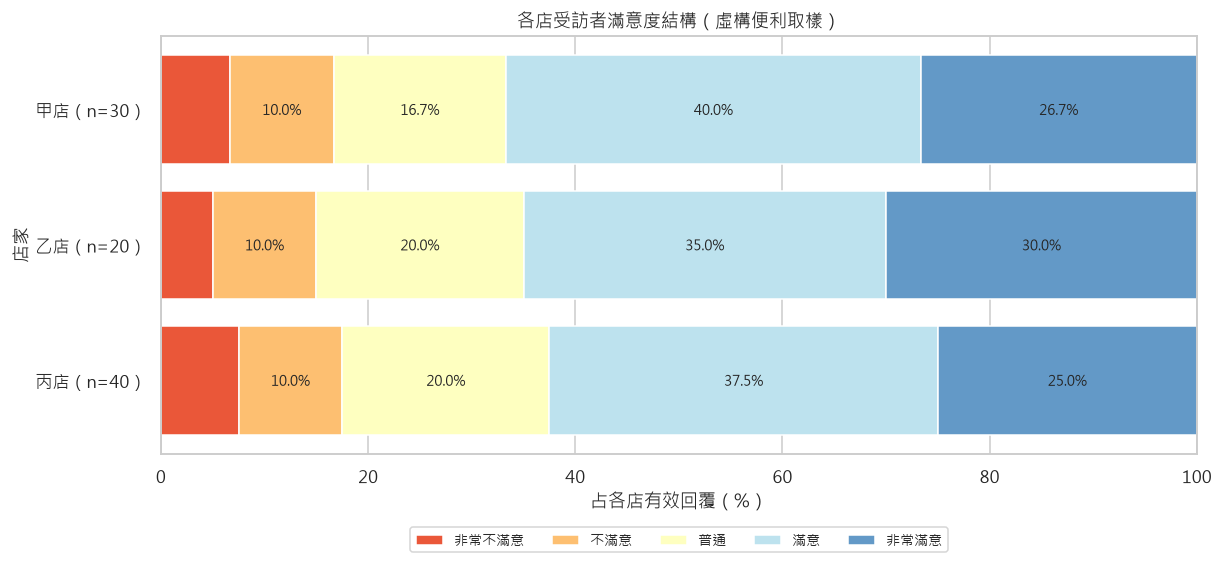

   非常不滿意   不滿意    普通    滿意  非常滿意
0    6.7  10.0  16.7  40.0  26.7
1    5.0  10.0  20.0  35.0  30.0
2    7.5  10.0  20.0  37.5  25.0


In [30]:
df = read_data("14_便當店滿意度次數.csv")
levels = ["非常不滿意", "不滿意", "普通", "滿意", "非常滿意"]
totals = df[levels].sum(axis=1)
percent = df[levels].div(totals, axis=0) * 100
colors = sns.color_palette("RdYlBu", n_colors=5)
fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
left = np.zeros(len(df))
for level, color in zip(levels, colors):
    values = percent[level].to_numpy()
    bars = ax.barh(df["店家"], values, left=left, label=level, color=color)
    ax.bar_label(bars, labels=[f"{v:.1f}%" if v >= 9 else "" for v in values], label_type="center", fontsize=9)
    left += values
ax.set_yticks(np.arange(len(df)), [f"{shop}（n={n}）" for shop, n in zip(df["店家"], totals)])
ax.invert_yaxis()
ax.set(title="各店受訪者滿意度結構（虛構便利取樣）", xlabel="占各店有效回覆（%）", ylabel="店家", xlim=(0, 100))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncols=5, fontsize=9)
plt.show()
print(percent.round(1))


**技術拆解：為什麼這樣寫？**

滿意度有由低到高的自然順序，不應按每店人數重新排序。Seaborn 的 barplot 沒有通用的 `stacked=True` 參數；此題用 Seaborn 配色、Matplotlib 堆疊。`left` 是橫向每段起點，作用相當於直向的 bottom。為避免窄段文字擠在一起，小比例不標字，但完整數字保留在表格。

**課堂操作與討論**

乙店滿意加非常滿意 13 人，甲店 20 人，可以直接說甲店滿意比例比較高嗎？

<details><summary>參考思路（先做再展開）</summary>

乙為 13/20=65%，甲為 20/30≈66.7%。原始人數本身不足以判斷比例；小差異與便利取樣也不足以推論所有顧客。

</details>


### 範例 30｜複選問卷的百分比可以超過一百

範例檔：[30_複選問卷的百分比可以超過一百.py](./Data_Visualization_src/bar_plot_examples/30_複選問卷的百分比可以超過一百.py)

檔案：`15_便當店改善複選.csv`。30 位受訪者可以勾多項，想知道哪些改善最被期待。


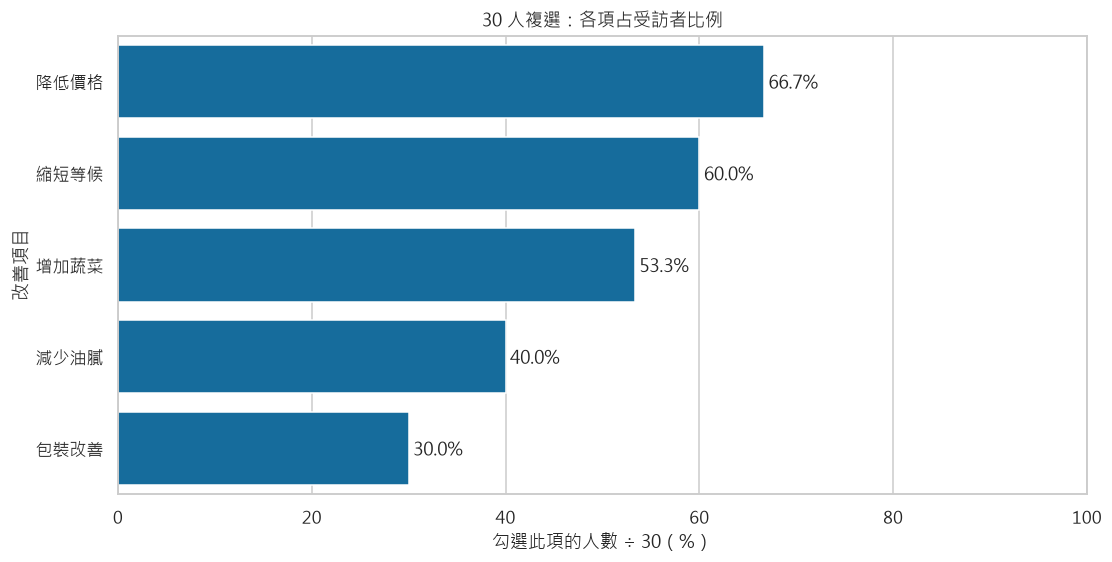

各項勾選率相加： 250.0 %


In [31]:
df = read_data("15_便當店改善複選.csv")
respondents = 30
df["受訪者勾選率"] = df["勾選人數"] / respondents * 100
df = df.sort_values("受訪者勾選率", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
sns.barplot(data=df, y="改善項目", x="受訪者勾選率", order=df["改善項目"].tolist(),
            estimator="mean", errorbar=None, color="#0072B2", ax=ax)
label_bars(ax, fmt="%.1f%%")
ax.set(title="30 人複選：各項占受訪者比例", xlabel="勾選此項的人數 ÷ 30（%）", ylabel="改善項目", xlim=(0, 100))
plt.show()
print("各項勾選率相加：", round(df["受訪者勾選率"].sum(), 1), "%")


**技術拆解：為什麼這樣寫？**

同一個人可以出現在多個選項，這些項目不是互斥部分，因此不適合堆疊成一個人的 100%。此題分母是 30 位有效受訪者；若改用總勾選次數 75，問的是「全部勾選之中各項占多少」，不是「多少人支持」。不同分母代表不同問題。

**課堂操作與討論**

降低價格的 20 人，占受訪者多少？占所有勾選多少？為什麼不能混用？

<details><summary>參考思路（先做再展開）</summary>

20/30≈66.7%；20/75≈26.7%。前者是人的支持率，後者是勾選次數組成；全部支持率合計 250% 合理。

</details>


### 分級練習與交付要求

請在 [工作單](./Data_Visualization_src/bar_plot_examples/練習題.md) 指定的檔名中完成程式，先不要看下面六題解答。每題都要寫一句資料觀察與一句限制；圖漂亮但統計量錯，仍需要修正。

| 題目 | 建議練習檔名 | 驗收 | 解答 |
|---|---|---|---|
| A 預算差額 | `練習_A_預算差額.py` | 正負方向、零基準、總額核對 | 31 |
| B 雞蛋比價 | `練習_B_雞蛋單價.py` | 先除以顆數、依單價排序、保留兩位小數 | 32 |
| C 早餐訂單 | `練習_C_品項營業額.py` | 份數與營業額各一張，不把列數當份數 | 33 |
| D 等候摘要 | `練習_D_等候中位數.py` | 中位數、原始點、各店人數 | 34 |
| E 支出結構 | `練習_E_住戶支出比例.py` | 各戶自己的分母、比例與總額 | 35 |
| F 便當團購 | `練習_F_便當團購報告.py` | 群組份數、各班總額、輸出 CSV 與圖 | 36 |

**加分延伸：** 自選洗衣店費用、手搖飲花費、家庭採買、通勤方式或周末活動支出，建立至少四個類別的資料。先寫「每列代表什麼」，再做 Matplotlib 與 Seaborn 兩版，確認統計量相同才比較外觀。

| 評量項目 | 配分 | 看得見的證據 |
|---|---:|---|
| 問題與資料定義 | 20 | 有期間、單位、每列意義與來源 |
| 統計與清理 | 30 | 分母、缺值、總額與平均選擇正確 |
| 圖形閱讀 | 20 | 零基準、順序、圖例、標籤清楚 |
| 技術說明 | 15 | 能解釋三個參數與一個資料轉換 |
| 結論限制 | 15 | 引用數字，不把圖當成因果證明 |

### 參考解答區

同一問題可以有不同的正確畫法，請比較自己的資料整理與統計意義，不只比較圖的顏色。


### 範例 31｜解答預算差額

範例檔：[31_解答預算差額.py](./Data_Visualization_src/bar_plot_examples/31_解答預算差額.py)

工作單 A；檔案：`05_預算與實際支出.csv`。先算差額，再畫相對零的長度。


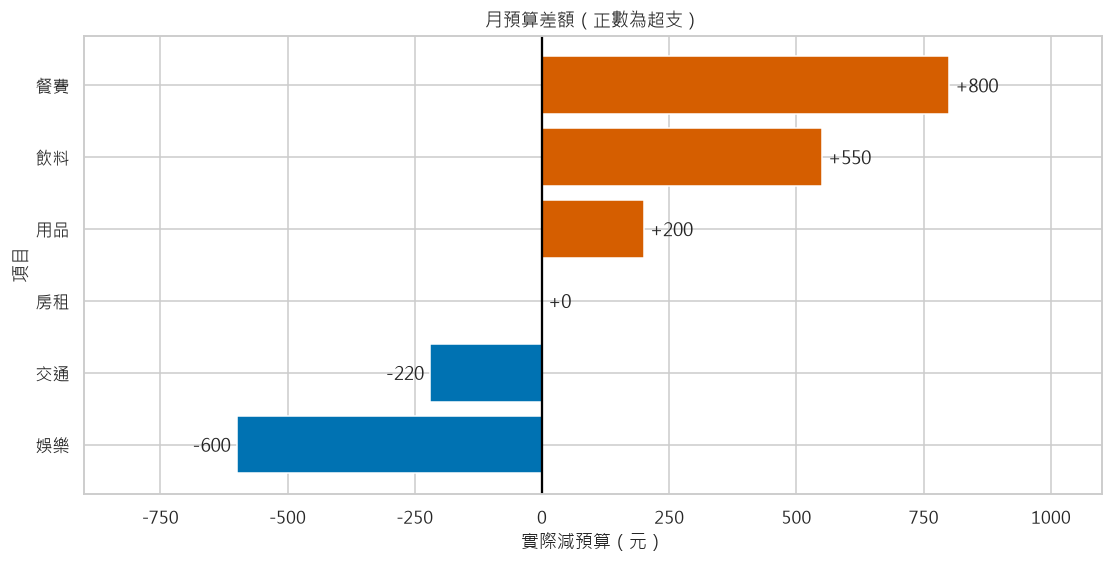

總差額： 730 元；只計超支項目： 1550 元


In [32]:
df = read_data("05_預算與實際支出.csv")
df["差額"] = df["實際"] - df["預算"]
df = df.sort_values("差額", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
bars = ax.barh(df["項目"], df["差額"], color=["#D55E00" if v > 0 else "#0072B2" for v in df["差額"]])
ax.invert_yaxis()
ax.axvline(0, color="black")
ax.bar_label(bars, fmt="%+.0f", padding=4)
ax.set(title="月預算差額（正數為超支）", xlabel="實際減預算（元）", ylabel="項目", xlim=(-900, 1100))
plt.show()
net = df["差額"].sum()
assert net == df["實際"].sum() - df["預算"].sum()
print("總差額：", net, "元；只計超支項目：", df["差額"].clip(lower=0).sum(), "元")


**技術拆解：為什麼這樣寫？**

總差額可用逐項相減後加總，也可用總實際減總預算，兩者應相同。`clip(lower=0)` 把節省項目的負差額轉為零，算的是另外一個指標「超支項目金額合計」。這個零是計算指標的截斷，不是填補未知資料。

**課堂操作與討論**

請核對兩個結果，說明為何不能都叫「總超支」。

<details><summary>參考思路（先做再展開）</summary>

總差額 730 元；超支項目合計 1550 元。交通和娛樂的節省共 820 元，所以淨差額較小。

</details>


### 範例 32｜解答雞蛋單價排序

範例檔：[32_解答雞蛋單價排序.py](./Data_Visualization_src/bar_plot_examples/32_解答雞蛋單價排序.py)

工作單 B；檔案：`10_超市雞蛋包裝比價.csv`。用 Seaborn 畫橫向單價排名。


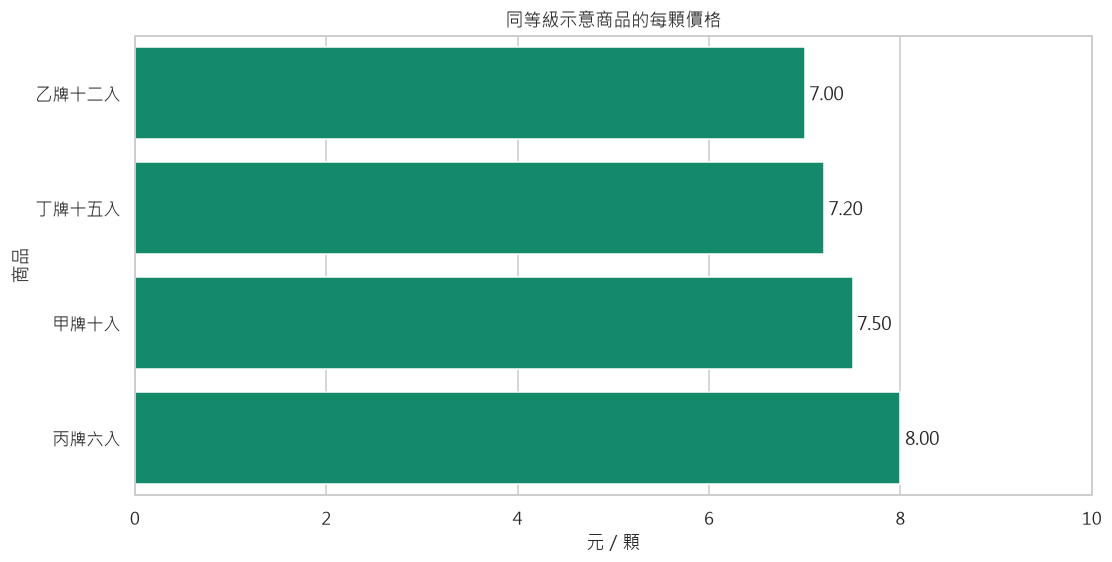

      商品   盒價  顆數  每顆單價
1  乙牌十二入   84  12   7.0
3  丁牌十五入  108  15   7.2
0   甲牌十入   75  10   7.5
2   丙牌六入   48   6   8.0


In [33]:
df = read_data("10_超市雞蛋包裝比價.csv")
assert df[["盒價", "顆數"]].notna().all().all()
assert (df["顆數"] > 0).all()
df["每顆單價"] = df["盒價"] / df["顆數"]
df = df.sort_values("每顆單價")
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
sns.barplot(data=df, x="每顆單價", y="商品", order=df["商品"].tolist(), estimator="mean", errorbar=None, color="#009E73", ax=ax)
label_bars(ax, fmt="%.2f")
ax.set(title="同等級示意商品的每顆價格", xlabel="元／顆", ylabel="商品", xlim=(0, 10))
plt.show()
print(df[["商品", "盒價", "顆數", "每顆單價"]])


**技術拆解：為什麼這樣寫？**

`assert` 條件不成立就停止，提醒資料需要處理，不會自動修好。此處每商品只有一列，mean 不改變單價；若有多次價格，平均單價要說明各次觀測的權重，不能直接當作實際採購成本。

**課堂操作與討論**

若某盒只有顆數沒有盒價，可以算單價嗎？把它補為零會產生什麼誤導？

<details><summary>參考思路（先做再展開）</summary>

不能，補零會把未知商品畫成免費。應保留缺漏並標示，或在清楚說明排除後比較已知商品。

</details>


### 範例 33｜解答品項份數與營業額

範例檔：[33_解答品項份數與營業額.py](./Data_Visualization_src/bar_plot_examples/33_解答品項份數與營業額.py)

工作單 C；檔案：`03_早餐店訂單明細.csv`。先檢查金額算式，再彙總。


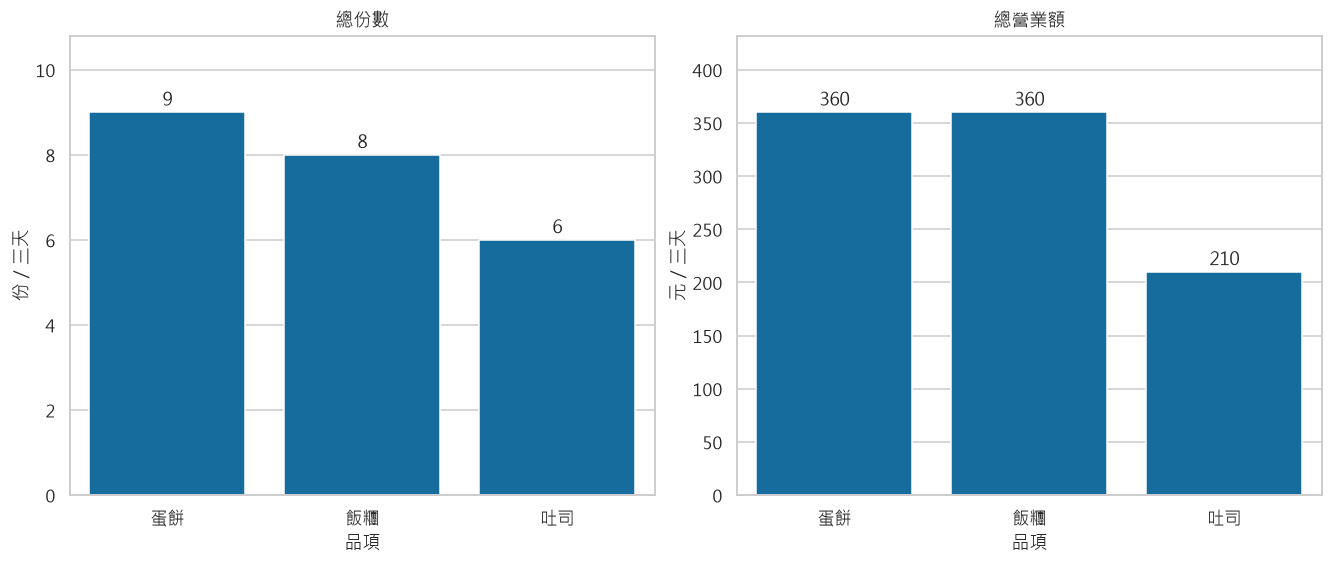

   品項  總份數  總營業額
0  吐司    6   210
1  蛋餅    9   360
2  飯糰    8   360
所有訂單合計： 930 元


In [34]:
df = read_data("03_早餐店訂單明細.csv")
assert (df["金額"] == df["份數"] * df["單價"]).all()
summary = df.groupby("品項", as_index=False).agg(總份數=("份數", "sum"), 總營業額=("金額", "sum"))
order = summary.sort_values("總份數", ascending=False)["品項"].tolist()
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
for ax, column, unit in zip(axes, ["總份數", "總營業額"], ["份／三天", "元／三天"]):
    sns.barplot(data=summary, x="品項", y=column, order=order, estimator="sum", errorbar=None, color="#0072B2", ax=ax)
    label_bars(ax)
    ax.set(title=column, xlabel="品項", ylabel=unit)
    ax.margins(y=0.2)
plt.show()
print(summary)
print("所有訂單合計：", df["金額"].sum(), "元")


**技術拆解：為什麼這樣寫？**

同一報告兩張圖可固定相同品項順序，讓讀者容易對照，而非每張各自重排。份數與營業額不能共用同一 y 軸，圖例或顏色也不能代替單位。金額資料若有折扣，驗證公式必須改成真正的交易規則。

**課堂操作與討論**

為何蛋餅賣 9 份、飯糰 8 份，但總營業額相同？能否推論兩者利潤也相同？

<details><summary>參考思路（先做再展開）</summary>

蛋餅每份 40、飯糰 45，均 360 元。成本未提供，所以不能比較利潤。全表合計 930 元。

</details>


### 範例 34｜解答等候中位數與樣本數

範例檔：[34_解答等候中位數與樣本數.py](./Data_Visualization_src/bar_plot_examples/34_解答等候中位數與樣本數.py)

工作單 D；檔案：`11_早餐店等候紀錄.csv`。希望看典型等待，也保留極端個案與不同樣本數。


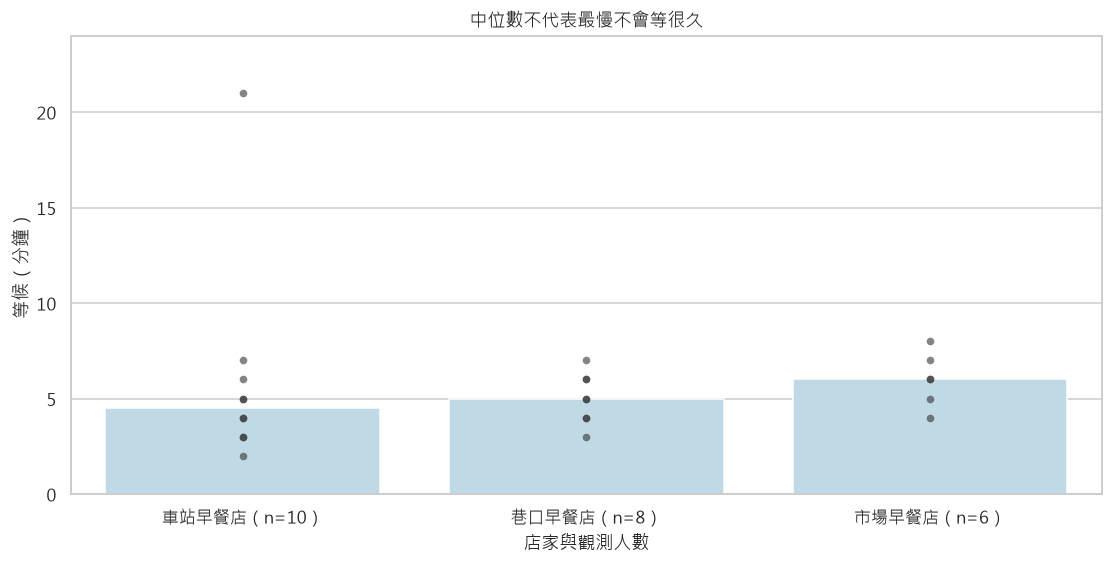

       size  median  max
店家                      
車站早餐店    10     4.5   21
巷口早餐店     8     5.0    7
市場早餐店     6     6.0    8


In [35]:
df = read_data("11_早餐店等候紀錄.csv")
summary = df.groupby("店家")["等候分鐘"].agg(["size", "median", "max"]).sort_values("median")
order = summary.index.tolist()
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
sns.barplot(data=df, x="店家", y="等候分鐘", order=order, estimator="median", errorbar=None, color="#B9DDEB", ax=ax)
sns.stripplot(data=df, x="店家", y="等候分鐘", order=order, jitter=False, color="#333333", alpha=0.6, ax=ax)
ax.set_xticks(range(len(order)), [f"{shop}（n={summary.loc[shop, 'size']:.0f}）" for shop in order])
ax.set(title="中位數不代表最慢不會等很久", xlabel="店家與觀測人數", ylabel="等候（分鐘）", ylim=(0, 24))
plt.show()
print(summary)


**技術拆解：為什麼這樣寫？**

排序依據中位數，類別標籤補上 n 告訴觀眾每組多少人。車站店中位數較低，但最大值達 21 分鐘；不同指標會支持不同閱讀角度。重疊的原始點不能當作人數清單，所以另外印出摘要。

**課堂操作與討論**

若你不能接受偶爾長等，只按中位數選店是否足夠？還需要什麼資料？

<details><summary>參考思路（先做再展開）</summary>

不足；還需更多時段、更多顧客、尖峰與離峰條件及尾端等待資訊。小樣本中的最大值也不是未來上限。

</details>


### 範例 35｜解答住戶支出比例

範例檔：[35_解答住戶支出比例.py](./Data_Visualization_src/bar_plot_examples/35_解答住戶支出比例.py)

工作單 E；檔案：`08_三戶租屋支出.csv`。每一戶用自己的總支出當分母，並在類別名稱保留總額。


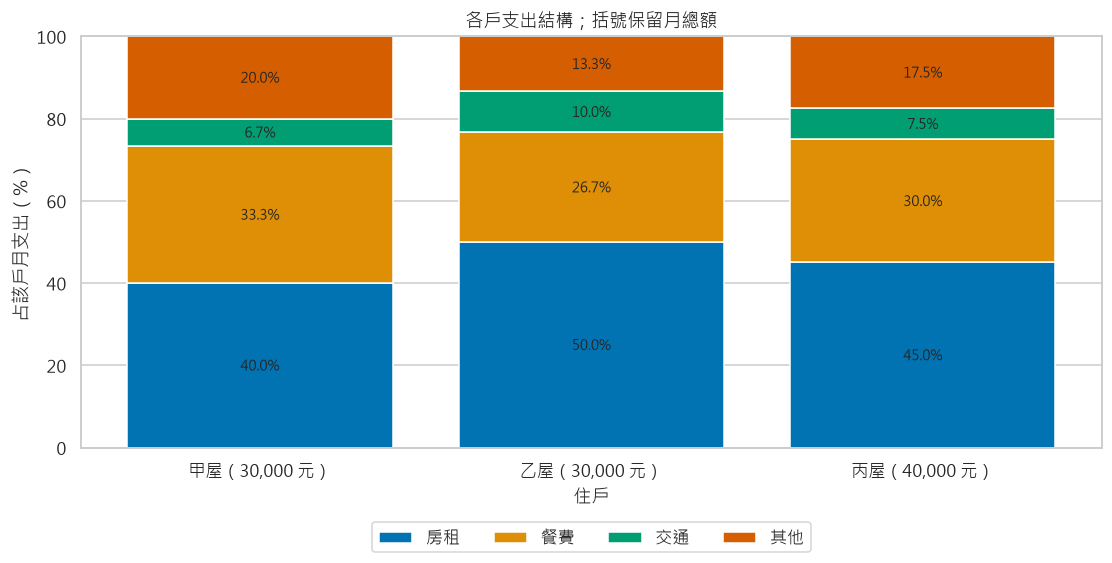

     房租     餐費     交通     其他
0  40.0  33.33   6.67  20.00
1  50.0  26.67  10.00  13.33
2  45.0  30.00   7.50  17.50


In [36]:
df = read_data("08_三戶租屋支出.csv")
parts = ["房租", "餐費", "交通", "其他"]
totals = df[parts].sum(axis=1)
percent = df[parts].div(totals, axis=0) * 100
assert np.allclose(percent.sum(axis=1), 100)
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
bottom = np.zeros(len(df))
for part, color in zip(parts, sns.color_palette("colorblind", 4)):
    bars = ax.bar(df["住戶"], percent[part], bottom=bottom, label=part, color=color)
    ax.bar_label(bars, fmt="%.1f%%", label_type="center", fontsize=9)
    bottom += percent[part].to_numpy()
ax.set_xticks(range(len(df)), [f"{house}（{total:,.0f} 元）" for house, total in zip(df["住戶"], totals)])
ax.set(title="各戶支出結構；括號保留月總額", xlabel="住戶", ylabel="占該戶月支出（%）", ylim=(0, 100))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncols=4)
plt.show()
print(percent.round(2))


**技術拆解：為什麼這樣寫？**

`np.allclose` 檢查每列總比例是否接近 100，而非要求浮點數完全一樣；電腦的小數運算可能有極小誤差。保留總額可避免讀者以為一樣高就表示花一樣多。這種圖適合看組成，若要精確比較交通費，另外畫交通費長條更直接。

**課堂操作與討論**

丙屋房租比例 45%，甲屋 40%，是否表示丙屋比較負擔不起？

<details><summary>參考思路（先做再展開）</summary>

不能，還沒有收入與資產等資料。這張圖分母是支出，不是收入；「房租占支出」和「房租占收入」是不同指標。

</details>


### 範例 36｜便當團購完整報告

範例檔：[36_便當團購完整報告.py](./Data_Visualization_src/bar_plot_examples/36_便當團購完整報告.py)

工作單 F／綜合專題；檔案：`16_練習便當訂購.csv`。班長要核對早晚班每種口味幾份、各班要收多少錢，最後交付圖與摘要。


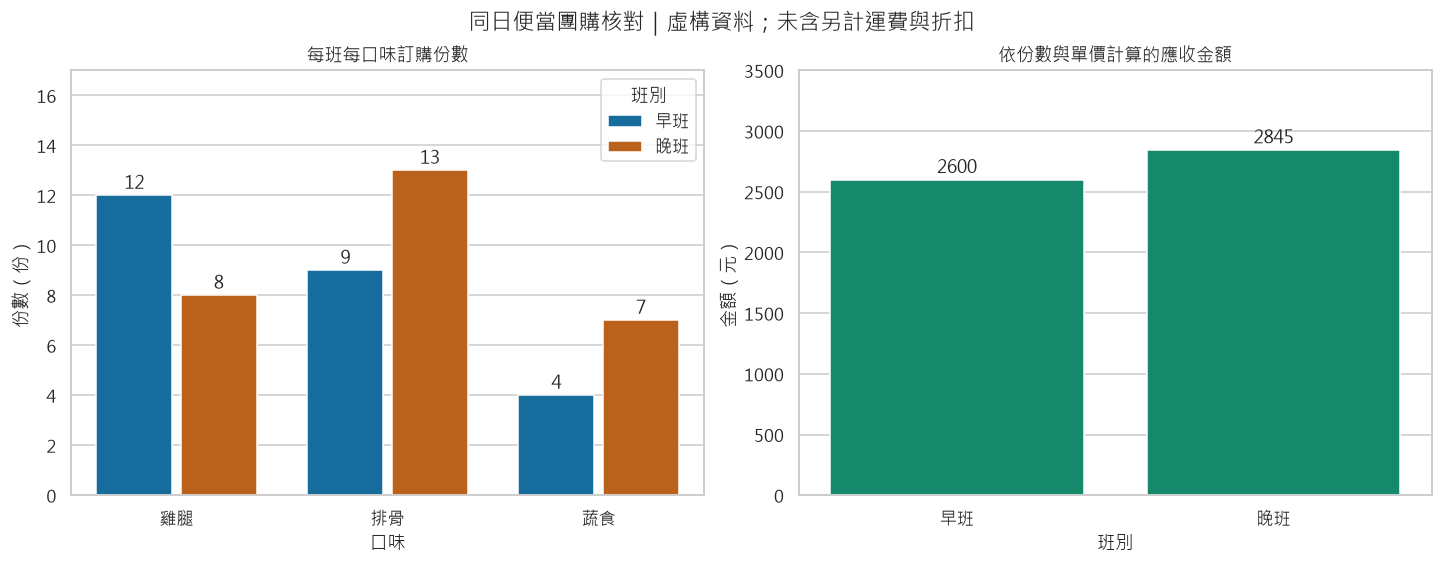

   班別  總份數  應收金額  每份平均金額
0  早班   25  2600  104.00
1  晚班   28  2845  101.61
共訂 53 份；應收 5445 元。


In [37]:
df = read_data("16_練習便當訂購.csv")
assert not df.duplicated(["班別", "口味"]).any()
assert (df["份數"] >= 0).all() and (df["單價"] > 0).all()
df["金額"] = df["份數"] * df["單價"]
summary = df.groupby("班別", as_index=False).agg(總份數=("份數", "sum"), 應收金額=("金額", "sum"))
summary["每份平均金額"] = summary["應收金額"] / summary["總份數"]
assert summary["總份數"].sum() == df["份數"].sum()
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
sns.barplot(data=df, x="口味", y="份數", hue="班別", order=["雞腿", "排骨", "蔬食"],
            hue_order=["早班", "晚班"], palette={"早班": "#0072B2", "晚班": "#D55E00"},
            estimator="sum", errorbar=None, gap=0.1, ax=axes[0])
sns.barplot(data=summary, x="班別", y="應收金額", order=["早班", "晚班"], estimator="sum",
            errorbar=None, color="#009E73", ax=axes[1])
axes[0].set(title="每班每口味訂購份數", xlabel="口味", ylabel="份數（份）", ylim=(0, 17))
axes[1].set(title="依份數與單價計算的應收金額", xlabel="班別", ylabel="金額（元）", ylim=(0, 3500))
for ax in axes:
    label_bars(ax)
fig.suptitle("同日便當團購核對｜虛構資料；未含另計運費與折扣")
fig.savefig(OUT / "36_便當團購報告.png", dpi=160, bbox_inches="tight")
fig.savefig(OUT / "36_便當團購報告.svg", bbox_inches="tight")
summary.to_csv(OUT / "36_各班應收摘要.csv", index=False, encoding="utf-8-sig")
df.to_csv(OUT / "36_便當訂購核對明細.csv", index=False, encoding="utf-8-sig")
plt.show()
print(summary.round(2))
print("共訂", df["份數"].sum(), "份；應收", df["金額"].sum(), "元。")


**技術拆解：為什麼這樣寫？**

每列已是班別與口味的彙總，所以不能用 countplot 數出六列當成六份便當。先算每列份數乘單價，再分班加總；平均每份費用必須用應收總額除以總份數，不是三個口味單價直接平均。

圖的左邊協助向店家核對份數，右邊協助班長收款，兩張圖單位不同。輸出原始核對明細與各班摘要，能回查每筆金額。題目沒提供運費與折扣，所以結論要保留這個範圍。

**課堂操作與討論**

請寫三句報告：總份數與總金額、兩班口味差異、尚未計入的費用。延伸：若全單另收 60 元運費，應如何分攤？先說規則再算。

<details><summary>參考思路（先做再展開）</summary>

早班 25 份、2600 元；晚班 28 份、2845 元；合計 53 份、5445 元。運費可按班均分或按份數比例分攤，但要先約定，並處理四捨五入尾差。

</details>


## 課後查閱與教師延伸

### 常見錯誤：先讀最後一行訊息，再回頭看資料

| 現象 | 常見原因 | 排查方式 |
|---|---|---|
| `NameError: DATA` | 重啟 Kernel 後未跑設定 | 先執行環境格 |
| 找不到 CSV | 只複製 Notebook 或改了檔案位置 | 保留完整目錄，印 DATA 確認 |
| `KeyError` | 欄名不一致、有空白 | `df.columns.tolist()` 逐字核對 |
| x、height 長度不同 | 只對一欄篩選或排序 | 成對資料按整列處理 |
| 同品項只看見一根卻數字怪 | 原始重複類別重疊 | 先 groupby 再 bar |
| 金額是字串 | 有逗號、元、空白 | 清理後 `pd.to_numeric(..., errors="raise")`，不要默默吞錯 |
| 中文變方框 | 缺中文字型或主題覆蓋 | 安裝字型後重啟；set_theme 同時傳 font |
| 標籤被切掉 | 數值軸上限不足 | 調整 ylim／xlim 與 layout |
| 長條高得像倍數差異 | 數值軸零點被截掉 | 回到零基準或改點圖 |
| barplot 比預期小 | 預設平均而不是加總 | 手算一組，檢查 estimator |
| countplot 每類都是 1 | 用摘要表數列數 | 用數值欄畫 barplot／bar |
| 關掉 errorbar 仍在平均 | 誤差線與估計是不同設定 | 明確選 estimator |
| `estimator=None` 不能用 | 把 lineplot 寫法搬到 barplot | 選 sum、mean、median 等代表值 |
| `palette` 出現警告 | 無 hue 卻用分組色盤 | 單色用 color，分組明確設定 hue |
| `gap` 參數不支援 | 舊版 Seaborn | 印版本，確認目前 Kernel 的套件 |
| 百分比總和大於 100 | 可能是複選，不一定錯 | 先查分母與項目是否互斥 |
| 堆疊超過正確總額 | 重複加上已含的費用 | 重新查資料定義，不能只修圖形 |
| 小組平均再平均不對 | 各組筆數不同 | 依題目選權重，或回到原始列計算 |
| 沒有誤差線 | 每組只有一筆、變異零或已關閉 | 不等於沒有不確定性 |

### 能手算才算真的理解

1. 三張訂單金額 40、80、120，平均與總額？**80 元／單、240 元。**
2. 訂單份數 1、2、3，用 countplot 得到幾筆？**3 筆，不是 6 份。**
3. 一盒 84 元 12 顆，單價？**7 元／顆。**
4. 預算 1000、實際 850，實際減預算？**−150 元，少花 150，不是負支出。**
5. 一組 2 人平均 100，另一組 8 人平均 50，十人平均？**60，而不是 75。**
6. 40 人可複選，某項 20 人，支持率？**50%，分母是 40 人。**
7. 每戶都畫成 100% 一樣高，是否花同樣多？**不一定，要看總額。**
8. 10、NaN、0 的資料，能把未知算成 0 求平均嗎？**不能；已知兩筆平均 5，不代表三筆完整平均。**
9. `barplot(errorbar=None)` 是否就是原始值？**不是，預設仍求平均。**
10. 沒有收入資料，能從房租占支出推論誰負擔最重？**不能，分母不是收入。**

### 教師可反覆使用的活動卡

- **先猜圖：** 給原始訂單，學生先手算份數、筆數、金額，再選 y 軸名稱。
- **找錯圖：** 給截斷零點、亂排滿意度、缺漏補零三種錯誤，要求說出哪個生活決策會被誤導。
- **需求翻譯：** 同桌扮演班長與資料整理者，一人只說需求，另一人選 sum、mean、count 與圖形，再互換角色。
- **同圖異解：** 一人重視低價，一人重視不用等待，從午餐／早餐圖提出各自選擇並列出資料不足。
- **程式接龍：** 一人寫讀檔、一人寫整理、一人寫作圖、一人寫結論；每人都要說明前後資料的每列意義。
- **圖表修復：** 把錯誤示範改成可交付版本，保留修改前後兩張圖，說明不是只有換顏色。
- **三句報告：** 一句含數字的觀察，一句可考慮的行動，一句限制；不准只說「比較高」「比較好」。

### 圖表交付前的自我檢查

1. 問題、期間、每列與每根長條的定義一致嗎？
2. 數值是總和、平均、中位數還是列數？圖上寫清楚了嗎？
3. 價格是否用同規格、同單位？比例的分母是否清楚？
4. 確認零、缺漏、未出現的類別分開處理了嗎？
5. 長條有合理零基準，類別順序與圖例一致嗎？
6. 群組是否需要並排而非堆疊？堆疊項目真的能相加嗎？
7. 平均有保留樣本數與必要的原始分布嗎？誤差線有定義嗎？
8. 能從摘要表核對圖上的高度，並避免把營業額叫利潤嗎？

### 官方文件：需要查參數時再讀

教材的生活情境、數字與解說為自製；以下官方文件供核對 API 與延伸閱讀。

- [Matplotlib bar：位置、寬度與 bottom](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html)
- [Matplotlib bar_label：長條標籤](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar_label.html)
- [Seaborn barplot：估計、分組與誤差線](https://seaborn.pydata.org/generated/seaborn.barplot.html)
- [Seaborn countplot：類別出現次數](https://seaborn.pydata.org/generated/seaborn.countplot.html)
- [Seaborn 統計估計與誤差區間](https://seaborn.pydata.org/tutorial/error_bars.html)

請帶著自己的圖回答：**我在比較什麼？每根高度怎麼算？這個差異可以支持什麼行動？還有哪些事不能只靠這張圖判斷？**
